In [1]:
from pathlib import Path
import numpy as np
import os

# ==============================
# CELL 1: Find and inspect raw MindBigData file
# ==============================

INPUT_DIR = Path("/kaggle/input")

print("Searching files inside /kaggle/input ...\n")

all_files = [p for p in INPUT_DIR.rglob("*") if p.is_file()]

if len(all_files) == 0:
    print("No files found in /kaggle/input. Please check if dataset is added to Kaggle notebook.")
else:
    print(f"Total files found: {len(all_files)}\n")

candidate_files = []

for file_path in all_files:
    try:
        with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
            first_valid_line = None
            
            for line in f:
                line = line.strip()
                if line:
                    first_valid_line = line
                    break
        
        if first_valid_line is None:
            continue
        
        # MindBigData row should start with TRAIN or TEST
        if not (first_valid_line.startswith("TRAIN,") or first_valid_line.startswith("TEST,")):
            continue
        
        dataset_text, numeric_text = first_valid_line.split(",", 1)
        values = np.fromstring(numeric_text, sep=",", dtype=np.float32)
        
        # Expected numeric format:
        # origin + digit_event + 784 image pixels + timestamp + EEG values
        fixed_values = 1 + 1 + 784 + 1
        eeg_values = len(values) - fixed_values
        
        if eeg_values > 0:
            candidate_files.append({
                "path": file_path,
                "size_mb": file_path.stat().st_size / (1024 * 1024),
                "dataset_text": dataset_text,
                "total_numeric_values": len(values),
                "eeg_values": eeg_values,
                "divisible_by_64": eeg_values % 64 == 0,
                "samples_per_channel": eeg_values // 64 if eeg_values % 64 == 0 else None
            })
            
    except Exception:
        continue


print("========== Candidate MindBigData Files ==========\n")

if len(candidate_files) == 0:
    print("No MindBigData-like raw file detected automatically.")
    print("\nAll files found:")
    for p in all_files:
        print(p)
else:
    for i, info in enumerate(candidate_files):
        print(f"[{i}] File path              : {info['path']}")
        print(f"    File size              : {info['size_mb']:.2f} MB")
        print(f"    First column           : {info['dataset_text']}")
        print(f"    Total numeric values   : {info['total_numeric_values']}")
        print(f"    Estimated EEG values   : {info['eeg_values']}")
        print(f"    Divisible by 64        : {info['divisible_by_64']}")
        print(f"    Samples per channel    : {info['samples_per_channel']}")
        
        if info["samples_per_channel"] == 400:
            print("    Interpretation         : This file is already segmented as EEG shape (64, 400)")
        elif info["samples_per_channel"] == 96000:
            print("    Interpretation         : This file may contain long continuous EEG shape (64, 96000)")
        elif info["samples_per_channel"] is not None:
            print(f"    Interpretation         : EEG shape seems to be (64, {info['samples_per_channel']})")
        else:
            print("    Interpretation         : EEG format unclear")
        
        print()

    # Pick first candidate as RAW_FILE for next cells
    RAW_FILE = str(candidate_files[0]["path"])
    
    print("========== Selected RAW_FILE for next cells ==========")
    print("RAW_FILE =", RAW_FILE)

Searching files inside /kaggle/input ...

Total files found: 1

========== Candidate MindBigData Files ==========

[0] File path              : /kaggle/input/datasets/tasnovaislam2008002/mnist-64/MindBigData64_Mnist2022-EEGv0.016.txt
    File size              : 518.72 MB
    First column           : TRAIN
    Total numeric values   : 26387
    Estimated EEG values   : 25600
    Divisible by 64        : True
    Samples per channel    : 400
    Interpretation         : This file is already segmented as EEG shape (64, 400)

========== Selected RAW_FILE for next cells ==========
RAW_FILE = /kaggle/input/datasets/tasnovaislam2008002/mnist-64/MindBigData64_Mnist2022-EEGv0.016.txt


In [2]:
from collections import Counter
from tqdm.auto import tqdm
import numpy as np

# If RAW_FILE is already selected from Cell 1, this will use it.
# Otherwise, manually paste your file path here.
try:
    RAW_FILE
except NameError:
    RAW_FILE = "/kaggle/input/datasets/tasnovaislam2008002/mnist-64/MindBigData64_Mnist2022-EEGv0.016.txt"

print("Using RAW_FILE:")
print(RAW_FILE)

total_rows = 0
valid_rows = 0
black_rows = 0
bad_rows = 0

source_counter = Counter()
label_counter = Counter()

with open(RAW_FILE, "r", encoding="utf-8", errors="ignore") as f:
    for line in tqdm(f, desc="Counting dataset rows"):
        total_rows += 1
        
        line = line.strip()
        
        if not line:
            bad_rows += 1
            continue
        
        try:
            dataset_text, numeric_text = line.split(",", 1)
            dataset_text = dataset_text.strip().upper()
            
            # Only need first two numeric values:
            # origin, digit_event
            parts = numeric_text.split(",", 3)
            
            origin = int(float(parts[0]))
            label = int(float(parts[1]))
            
            source_counter[dataset_text] += 1
            label_counter[label] += 1
            
            if label == -1:
                black_rows += 1
            elif 0 <= label <= 9:
                valid_rows += 1
            else:
                bad_rows += 1
                
        except Exception:
            bad_rows += 1

print("\n========== ORIGINAL DATASET SUMMARY ==========")
print("Total rows in file         :", total_rows)
print("Valid digit rows 0-9       :", valid_rows)
print("Black signal rows label -1 :", black_rows)
print("Bad/invalid rows           :", bad_rows)

print("\n========== SOURCE DISTRIBUTION ==========")
for source, count in source_counter.items():
    print(f"{source}: {count}")

print("\n========== LABEL DISTRIBUTION ==========")
for label in sorted(label_counter.keys()):
    print(f"Label {label}: {label_counter[label]}")

print("\n========== POSSIBLE WINDOWED DATA COUNT ==========")

original_length = 400

window_settings = [
    (400, 400),
    (200, 200),
    (200, 100),
    (200, 50),
    (200, 25),
    (100, 50),
    (100, 25),
]

for window_length, stride in window_settings:
    if window_length > original_length:
        num_windows_per_sample = 0
    else:
        num_windows_per_sample = ((original_length - window_length) // stride) + 1
    
    total_windowed_samples = valid_rows * num_windows_per_sample
    
    print(
        f"Window length = {window_length:3d}, "
        f"Stride = {stride:3d} -> "
        f"{num_windows_per_sample:2d} windows/original sample -> "
        f"Total X-Y pairs = {total_windowed_samples}"
    )

Using RAW_FILE:
/kaggle/input/datasets/tasnovaislam2008002/mnist-64/MindBigData64_Mnist2022-EEGv0.016.txt


Counting dataset rows: 0it [00:00, ?it/s]


========== ORIGINAL DATASET SUMMARY ==========
Total rows in file         : 2332
Valid digit rows 0-9       : 1166
Black signal rows label -1 : 1166
Bad/invalid rows           : 0

========== SOURCE DISTRIBUTION ==========
TRAIN: 2332

========== LABEL DISTRIBUTION ==========
Label -1: 1166
Label 0: 114
Label 1: 139
Label 2: 115
Label 3: 111
Label 4: 121
Label 5: 104
Label 6: 107
Label 7: 138
Label 8: 102
Label 9: 115

========== POSSIBLE WINDOWED DATA COUNT ==========
Window length = 400, Stride = 400 ->  1 windows/original sample -> Total X-Y pairs = 1166
Window length = 200, Stride = 200 ->  2 windows/original sample -> Total X-Y pairs = 2332
Window length = 200, Stride = 100 ->  3 windows/original sample -> Total X-Y pairs = 3498
Window length = 200, Stride =  50 ->  5 windows/original sample -> Total X-Y pairs = 5830
Window length = 200, Stride =  25 ->  9 windows/original sample -> Total X-Y pairs = 10494
Window length = 100, Stride =  50 ->  7 windows/original sample -> Total X

========== ONE VALID SAMPLE INFO ==========
Dataset    : TRAIN
Origin     : 0
Label      : 5
Timestamp  : 1661347200.0
Image shape: (28, 28)
EEG shape  : (64, 400)

EEG dtype  : float32
Image dtype: uint8

EEG min/max: -111.79835 99.4289
Image min/max: 0 255


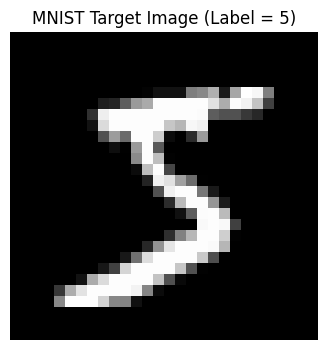

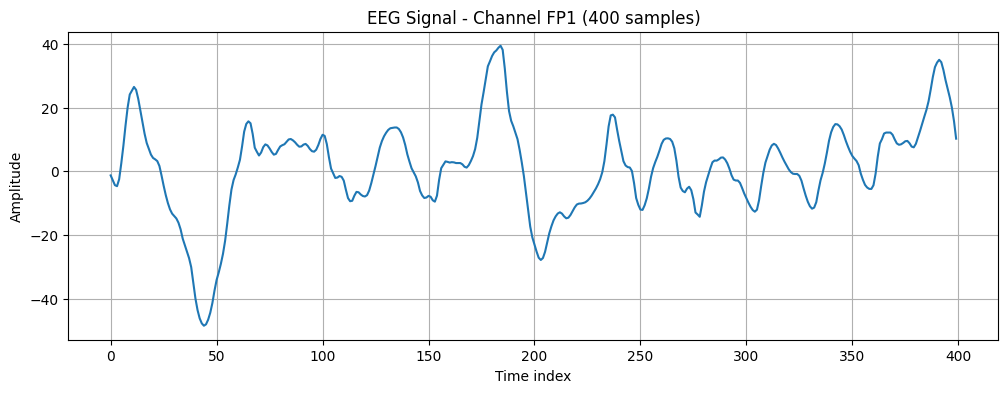

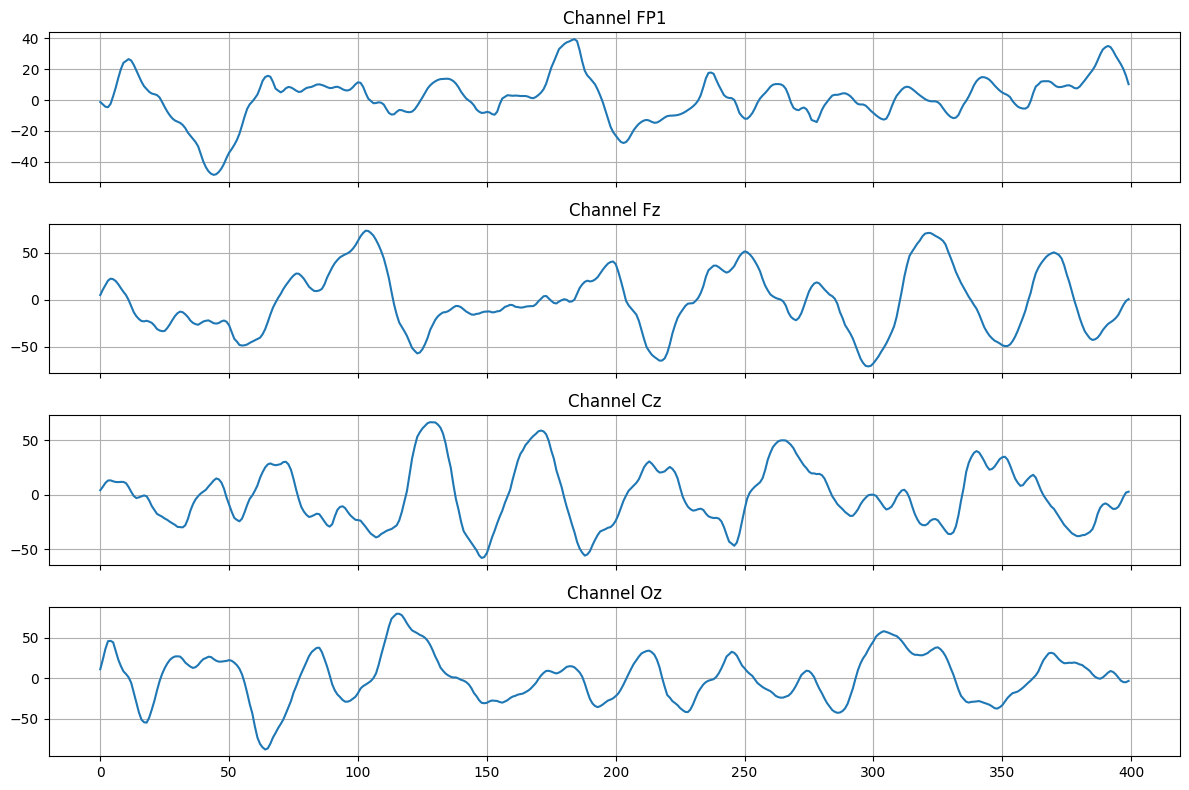

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# CELL 3: Parse one valid sample and visualize
# ==============================

NUM_CHANNELS = 64
SAMPLES_PER_CHANNEL = 400
NUM_PIXELS = 784

CHANNEL_NAMES = [
    "FP1", "FPz", "FP2", "AF3", "AFz", "AF4", "F7", "F5",
    "F3", "F1", "Fz", "F2", "F4", "F6", "F8", "FT7",
    "FC5", "FC3", "FC1", "FCz", "FC2", "FC4", "FC6", "FT8",
    "T7", "C5", "C3", "C1", "Cz", "CCPz", "C2", "C4",
    "C6", "T8", "TP7", "CP5", "CP3", "CP1", "CPz", "CP2",
    "CP4", "CP6", "TP8", "P7", "P5", "P3", "P1", "Pz",
    "P2", "P4", "P6", "P8", "PO7", "PO5", "PO3", "POz",
    "PO4", "PO6", "PO8", "CB1", "O1", "Oz", "O2", "CB2"
]

def parse_valid_sample_from_line(line):
    line = line.strip()
    dataset_text, numeric_text = line.split(",", 1)
    dataset_text = dataset_text.strip().upper()

    values = np.fromstring(numeric_text, sep=",", dtype=np.float32)

    origin = int(values[0])
    label = int(values[1])

    image = values[2:2+NUM_PIXELS].reshape(28, 28).astype(np.uint8)

    timestamp = values[2+NUM_PIXELS]

    eeg = values[2+NUM_PIXELS+1:]
    eeg = eeg.reshape(NUM_CHANNELS, SAMPLES_PER_CHANNEL).astype(np.float32)

    return {
        "dataset": dataset_text,
        "origin": origin,
        "label": label,
        "image": image,
        "timestamp": timestamp,
        "eeg": eeg
    }

# first valid sample (label 0-9) load করবো
sample = None

with open(RAW_FILE, "r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        
        parsed = parse_valid_sample_from_line(line)
        
        if 0 <= parsed["label"] <= 9:
            sample = parsed
            break

# check
if sample is None:
    print("No valid sample found.")
else:
    print("========== ONE VALID SAMPLE INFO ==========")
    print("Dataset    :", sample["dataset"])
    print("Origin     :", sample["origin"])
    print("Label      :", sample["label"])
    print("Timestamp  :", sample["timestamp"])
    print("Image shape:", sample["image"].shape)
    print("EEG shape  :", sample["eeg"].shape)

    print("\nEEG dtype  :", sample["eeg"].dtype)
    print("Image dtype:", sample["image"].dtype)

    print("\nEEG min/max:", sample["eeg"].min(), sample["eeg"].max())
    print("Image min/max:", sample["image"].min(), sample["image"].max())

    # image visualize
    plt.figure(figsize=(4,4))
    plt.imshow(sample["image"], cmap="gray")
    plt.title(f"MNIST Target Image (Label = {sample['label']})")
    plt.axis("off")
    plt.show()

    # first EEG channel plot
    plt.figure(figsize=(12,4))
    plt.plot(sample["eeg"][0])
    plt.title(f"EEG Signal - Channel {CHANNEL_NAMES[0]} ({sample['eeg'][0].shape[0]} samples)")
    plt.xlabel("Time index")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.show()

    # 4 channels quick look
    fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)

    chosen_channels = [0, 10, 28, 61]  # FP1, Fz, Cz, Oz roughly
    for ax, ch in zip(axes, chosen_channels):
        ax.plot(sample["eeg"][ch])
        ax.set_title(f"Channel {CHANNEL_NAMES[ch]}")
        ax.grid(True)

    plt.tight_layout()
    plt.show()

Collected valid samples: 20
Sample 0: Label=5, Image shape=(28, 28), EEG shape=(64, 400), EEG min=-111.80, EEG max=99.43
Sample 1: Label=0, Image shape=(28, 28), EEG shape=(64, 400), EEG min=-94.70, EEG max=96.84
Sample 2: Label=4, Image shape=(28, 28), EEG shape=(64, 400), EEG min=-101.27, EEG max=111.45
Sample 3: Label=2, Image shape=(28, 28), EEG shape=(64, 400), EEG min=-94.40, EEG max=113.45
Sample 4: Label=1, Image shape=(28, 28), EEG shape=(64, 400), EEG min=-94.89, EEG max=101.58


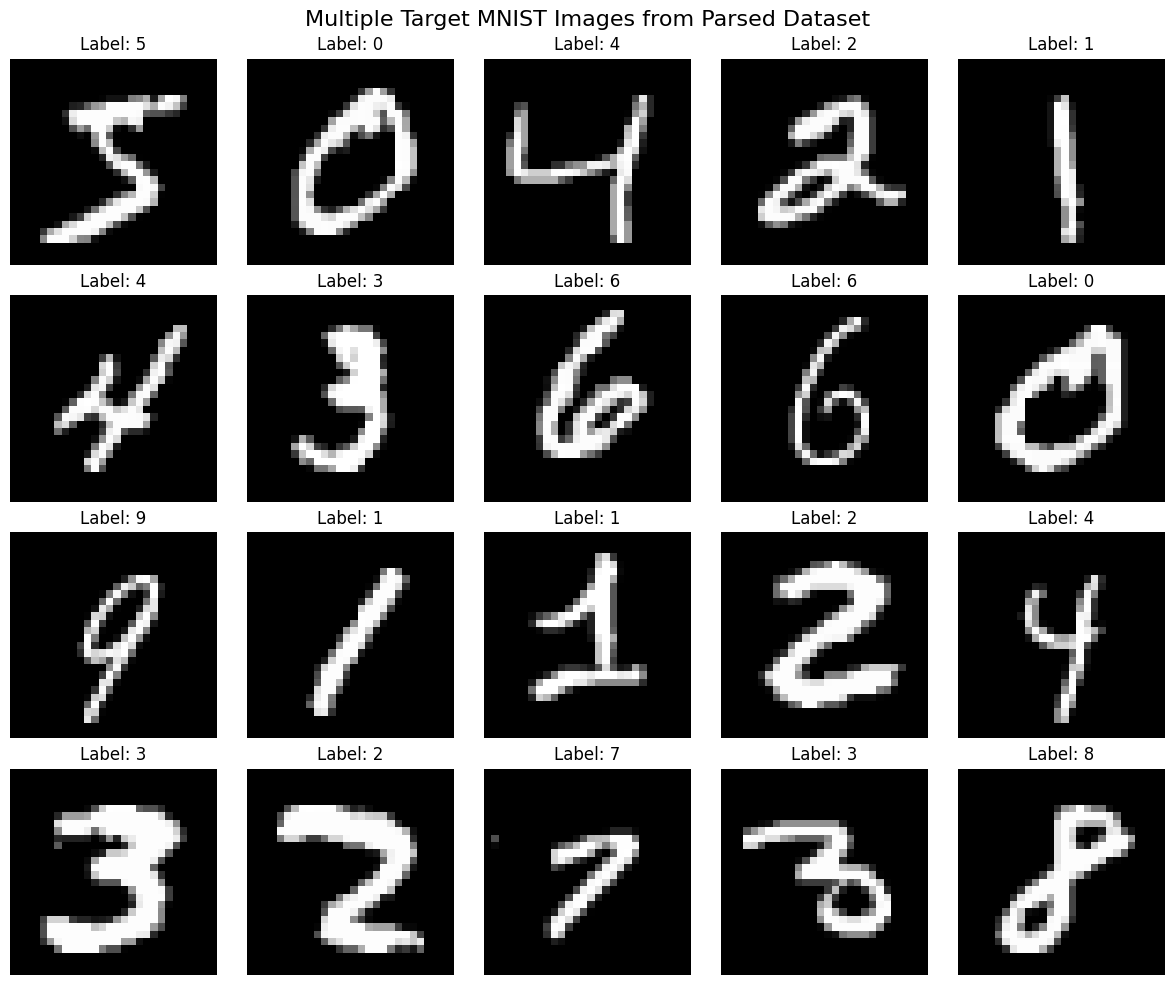

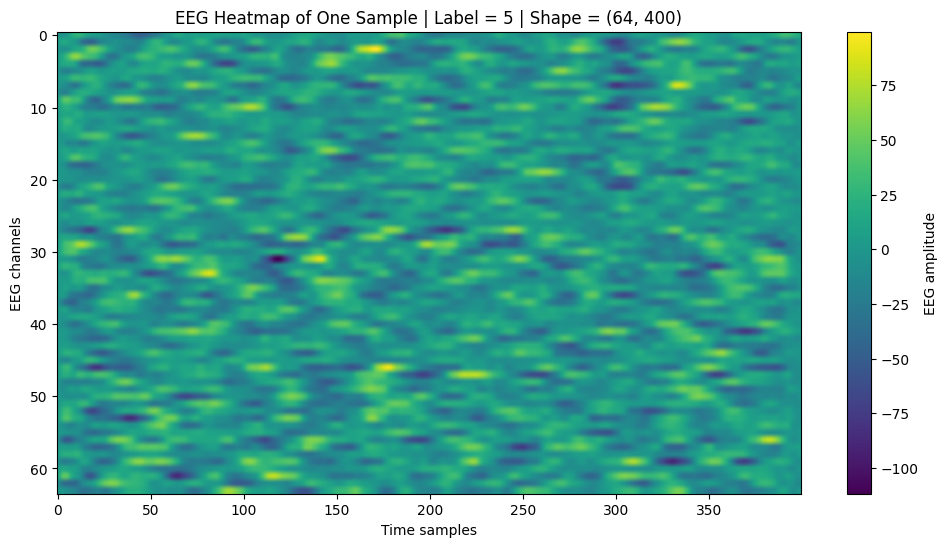

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# CELL 4: Check multiple valid samples
# ==============================

num_samples_to_show = 20

valid_samples = []

with open(RAW_FILE, "r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        
        parsed = parse_valid_sample_from_line(line)
        
        if 0 <= parsed["label"] <= 9:
            valid_samples.append(parsed)
        
        if len(valid_samples) >= num_samples_to_show:
            break

print(f"Collected valid samples: {len(valid_samples)}")

for i, s in enumerate(valid_samples[:5]):
    print(
        f"Sample {i}: "
        f"Label={s['label']}, "
        f"Image shape={s['image'].shape}, "
        f"EEG shape={s['eeg'].shape}, "
        f"EEG min={s['eeg'].min():.2f}, "
        f"EEG max={s['eeg'].max():.2f}"
    )

# Show target MNIST images
cols = 5
rows = int(np.ceil(num_samples_to_show / cols))

plt.figure(figsize=(12, 2.5 * rows))

for i, sample in enumerate(valid_samples):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(sample["image"], cmap="gray")
    plt.title(f"Label: {sample['label']}")
    plt.axis("off")

plt.suptitle("Multiple Target MNIST Images from Parsed Dataset", fontsize=16)
plt.tight_layout()
plt.show()

# Show EEG heatmap of one sample
sample_id = 0
eeg = valid_samples[sample_id]["eeg"]
label = valid_samples[sample_id]["label"]

plt.figure(figsize=(12, 6))
plt.imshow(eeg, aspect="auto", cmap="viridis")
plt.colorbar(label="EEG amplitude")
plt.title(f"EEG Heatmap of One Sample | Label = {label} | Shape = {eeg.shape}")
plt.xlabel("Time samples")
plt.ylabel("EEG channels")
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
from collections import Counter
import numpy as np
import json
import os

# ==============================
# CELL 5: Original-level stratified split
# ==============================

RANDOM_SEED = 42

# Split ratio
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

valid_meta = []

with open(RAW_FILE, "r", encoding="utf-8", errors="ignore") as f:
    for line_number, line in enumerate(f):
        line = line.strip()
        if not line:
            continue
        
        try:
            dataset_text, numeric_text = line.split(",", 1)
            dataset_text = dataset_text.strip().upper()
            
            parts = numeric_text.split(",", 3)
            origin = int(float(parts[0]))
            label = int(float(parts[1]))
            
            if 0 <= label <= 9:
                valid_meta.append({
                    "line_number": line_number,
                    "dataset": dataset_text,
                    "origin": origin,
                    "label": label
                })
                
        except Exception as e:
            continue

print("Total valid original samples:", len(valid_meta))

labels = np.array([item["label"] for item in valid_meta])
indices = np.arange(len(valid_meta))

# First: train vs temp
train_indices, temp_indices, train_labels, temp_labels = train_test_split(
    indices,
    labels,
    test_size=(1 - TRAIN_RATIO),
    random_state=RANDOM_SEED,
    stratify=labels
)

# Second: val vs test
val_size_inside_temp = VAL_RATIO / (VAL_RATIO + TEST_RATIO)

val_indices, test_indices, val_labels, test_labels = train_test_split(
    temp_indices,
    temp_labels,
    test_size=(1 - val_size_inside_temp),
    random_state=RANDOM_SEED,
    stratify=temp_labels
)

split_dict = {
    "train": train_indices.tolist(),
    "val": val_indices.tolist(),
    "test": test_indices.tolist()
}

print("\n========== ORIGINAL SAMPLE SPLIT ==========")
print("Train original samples:", len(train_indices))
print("Val original samples  :", len(val_indices))
print("Test original samples :", len(test_indices))

print("\n========== LABEL DISTRIBUTION: TRAIN ==========")
print(dict(sorted(Counter(train_labels).items())))

print("\n========== LABEL DISTRIBUTION: VAL ==========")
print(dict(sorted(Counter(val_labels).items())))

print("\n========== LABEL DISTRIBUTION: TEST ==========")
print(dict(sorted(Counter(test_labels).items())))

# Window count estimation
WINDOW_LENGTH = 200
STRIDE = 25
ORIGINAL_EEG_LENGTH = 400

windows_per_original = ((ORIGINAL_EEG_LENGTH - WINDOW_LENGTH) // STRIDE) + 1

print("\n========== FUTURE WINDOWED DATA COUNT ==========")
print("Window length:", WINDOW_LENGTH)
print("Stride       :", STRIDE)
print("Windows per original sample:", windows_per_original)

print("Train windowed samples:", len(train_indices) * windows_per_original)
print("Val windowed samples  :", len(val_indices) * windows_per_original)
print("Test windowed samples :", len(test_indices) * windows_per_original)

# Save split metadata
OUTPUT_DIR = "/kaggle/working/mindbig_processed"
os.makedirs(OUTPUT_DIR, exist_ok=True)

split_save_path = os.path.join(OUTPUT_DIR, "original_level_split.json")

save_data = {
    "random_seed": RANDOM_SEED,
    "train_ratio": TRAIN_RATIO,
    "val_ratio": VAL_RATIO,
    "test_ratio": TEST_RATIO,
    "window_length": WINDOW_LENGTH,
    "stride": STRIDE,
    "valid_meta": valid_meta,
    "split_indices": split_dict
}

with open(split_save_path, "w") as f:
    json.dump(save_data, f, indent=2)

print("\nSplit metadata saved to:")
print(split_save_path)

Total valid original samples: 1166

========== ORIGINAL SAMPLE SPLIT ==========
Train original samples: 816
Val original samples  : 175
Test original samples : 175

========== LABEL DISTRIBUTION: TRAIN ==========
{np.int64(0): 80, np.int64(1): 97, np.int64(2): 80, np.int64(3): 78, np.int64(4): 85, np.int64(5): 73, np.int64(6): 75, np.int64(7): 97, np.int64(8): 71, np.int64(9): 80}

========== LABEL DISTRIBUTION: VAL ==========
{np.int64(0): 17, np.int64(1): 21, np.int64(2): 18, np.int64(3): 17, np.int64(4): 18, np.int64(5): 15, np.int64(6): 16, np.int64(7): 20, np.int64(8): 15, np.int64(9): 18}

========== LABEL DISTRIBUTION: TEST ==========
{np.int64(0): 17, np.int64(1): 21, np.int64(2): 17, np.int64(3): 16, np.int64(4): 18, np.int64(5): 16, np.int64(6): 16, np.int64(7): 21, np.int64(8): 16, np.int64(9): 17}

========== FUTURE WINDOWED DATA COUNT ==========
Window length: 200
Stride       : 25
Windows per original sample: 9
Train windowed samples: 7344
Val windowed samples  : 1575
Tes

In [6]:
import os
import json
import h5py
import numpy as np
from tqdm.auto import tqdm
from collections import Counter

# ==============================
# CELL 6: Create windowed X-Y dataset and save as HDF5
# ==============================

OUTPUT_DIR = "/kaggle/working/mindbig_processed"
SPLIT_JSON_PATH = os.path.join(OUTPUT_DIR, "original_level_split.json")
H5_SAVE_PATH = os.path.join(OUTPUT_DIR, "mindbig_64ch_windowed_200_stride25.h5")

NUM_CHANNELS = 64
ORIGINAL_EEG_LENGTH = 400
WINDOW_LENGTH = 200
STRIDE = 25
NUM_PIXELS = 784

NORMALIZE_EEG = True

window_starts = list(range(0, ORIGINAL_EEG_LENGTH - WINDOW_LENGTH + 1, STRIDE))

print("Window starts:", window_starts)
print("Number of windows per original sample:", len(window_starts))


def normalize_eeg_window_channelwise(eeg_window):
    """
    eeg_window shape: (64, 200)

    এখানে প্রতিটা EEG channel আলাদাভাবে normalize করা হচ্ছে।
    Formula:
        x_norm = (x - mean) / std

    কেন করছি?
    EEG amplitude channel-to-channel vary করে।
    Normalize করলে model stable training পায়।
    """
    mean = eeg_window.mean(axis=1, keepdims=True)
    std = eeg_window.std(axis=1, keepdims=True)
    eeg_window = (eeg_window - mean) / (std + 1e-6)
    return eeg_window.astype(np.float32)


def parse_valid_sample_from_line_for_h5(line):
    """
    Raw line থেকে one valid sample parse করবে.

    Output:
        label: int
        origin: int
        image: (28, 28), uint8
        eeg: (64, 400), float32
    """
    line = line.strip()
    dataset_text, numeric_text = line.split(",", 1)

    values = np.fromstring(numeric_text, sep=",", dtype=np.float32)

    origin = int(values[0])
    label = int(values[1])

    if not (0 <= label <= 9):
        return None

    image_start = 2
    image_end = image_start + NUM_PIXELS

    image = values[image_start:image_end]
    image = np.clip(image, 0, 255).reshape(28, 28).astype(np.uint8)

    timestamp_index = image_end
    timestamp = float(values[timestamp_index])

    eeg_start = timestamp_index + 1
    eeg = values[eeg_start:]
    eeg = eeg.reshape(NUM_CHANNELS, ORIGINAL_EEG_LENGTH).astype(np.float32)

    return {
        "origin": origin,
        "label": label,
        "image": image,
        "timestamp": timestamp,
        "eeg": eeg
    }


# Load original-level split info
with open(SPLIT_JSON_PATH, "r") as f:
    split_data = json.load(f)

valid_meta = split_data["valid_meta"]
split_indices = split_data["split_indices"]

train_original_count = len(split_indices["train"])
val_original_count = len(split_indices["val"])
test_original_count = len(split_indices["test"])

train_window_count = train_original_count * len(window_starts)
val_window_count = val_original_count * len(window_starts)
test_window_count = test_original_count * len(window_starts)

print("\n========== Expected Windowed Dataset Size ==========")
print("Train windows:", train_window_count)
print("Val windows  :", val_window_count)
print("Test windows :", test_window_count)

# Map valid original sample index -> split name
valid_index_to_split = {}

for split_name, idx_list in split_indices.items():
    for idx in idx_list:
        valid_index_to_split[int(idx)] = split_name

print("\nTotal valid indices in split map:", len(valid_index_to_split))


def create_split_group(h5, split_name, total_windows):
    group = h5.create_group(split_name)

    group.create_dataset(
        "eeg",
        shape=(total_windows, NUM_CHANNELS, WINDOW_LENGTH),
        dtype=np.float32,
        chunks=(min(128, total_windows), NUM_CHANNELS, WINDOW_LENGTH)
    )

    group.create_dataset(
        "image",
        shape=(total_windows, 28, 28),
        dtype=np.uint8,
        chunks=(min(128, total_windows), 28, 28)
    )

    group.create_dataset(
        "label",
        shape=(total_windows,),
        dtype=np.int64,
        chunks=(min(128, total_windows),)
    )

    group.create_dataset(
        "origin",
        shape=(total_windows,),
        dtype=np.int32,
        chunks=(min(128, total_windows),)
    )

    group.create_dataset(
        "original_valid_index",
        shape=(total_windows,),
        dtype=np.int32,
        chunks=(min(128, total_windows),)
    )

    group.create_dataset(
        "window_start",
        shape=(total_windows,),
        dtype=np.int32,
        chunks=(min(128, total_windows),)
    )

    return group


# Create HDF5 and fill it
if os.path.exists(H5_SAVE_PATH):
    os.remove(H5_SAVE_PATH)

write_pointer = {
    "train": 0,
    "val": 0,
    "test": 0
}

with h5py.File(H5_SAVE_PATH, "w") as h5:
    h5.attrs["description"] = "MindBigData Custom Cap 64 windowed EEG-to-image dataset"
    h5.attrs["original_eeg_shape"] = "(64, 400)"
    h5.attrs["windowed_eeg_shape"] = f"(64, {WINDOW_LENGTH})"
    h5.attrs["image_shape"] = "(28, 28)"
    h5.attrs["window_length"] = WINDOW_LENGTH
    h5.attrs["stride"] = STRIDE
    h5.attrs["normalization"] = "channel-wise z-score per EEG window" if NORMALIZE_EEG else "none"
    h5.attrs["note"] = "Split was done at original sample level before windowing to avoid data leakage."

    create_split_group(h5, "train", train_window_count)
    create_split_group(h5, "val", val_window_count)
    create_split_group(h5, "test", test_window_count)

    valid_sample_index = -1

    with open(RAW_FILE, "r", encoding="utf-8", errors="ignore") as f:
        for line in tqdm(f, desc="Creating windowed dataset"):
            parsed = parse_valid_sample_from_line_for_h5(line)

            if parsed is None:
                continue

            valid_sample_index += 1

            split_name = valid_index_to_split[valid_sample_index]
            group = h5[split_name]

            eeg = parsed["eeg"]
            image = parsed["image"]
            label = parsed["label"]
            origin = parsed["origin"]

            for start in window_starts:
                eeg_window = eeg[:, start:start + WINDOW_LENGTH]

                if NORMALIZE_EEG:
                    eeg_window = normalize_eeg_window_channelwise(eeg_window)

                ptr = write_pointer[split_name]

                group["eeg"][ptr] = eeg_window
                group["image"][ptr] = image
                group["label"][ptr] = label
                group["origin"][ptr] = origin
                group["original_valid_index"][ptr] = valid_sample_index
                group["window_start"][ptr] = start

                write_pointer[split_name] += 1

print("\n========== Writing Finished ==========")
print("Saved HDF5 file:")
print(H5_SAVE_PATH)

print("\nWrite pointer check:")
print(write_pointer)

# Final verification
with h5py.File(H5_SAVE_PATH, "r") as h5:
    print("\n========== HDF5 Verification ==========")

    for split_name in ["train", "val", "test"]:
        print(f"\nSplit: {split_name}")
        print("EEG shape  :", h5[split_name]["eeg"].shape)
        print("Image shape:", h5[split_name]["image"].shape)
        print("Label shape:", h5[split_name]["label"].shape)

        labels = h5[split_name]["label"][:]
        print("Label distribution:", dict(sorted(Counter(labels).items())))

        sample_eeg = h5[split_name]["eeg"][0]
        sample_img = h5[split_name]["image"][0]

        print("Sample EEG min/max:", sample_eeg.min(), sample_eeg.max())
        print("Sample image min/max:", sample_img.min(), sample_img.max())

Window starts: [0, 25, 50, 75, 100, 125, 150, 175, 200]
Number of windows per original sample: 9

========== Expected Windowed Dataset Size ==========
Train windows: 7344
Val windows  : 1575
Test windows : 1575

Total valid indices in split map: 1166


Creating windowed dataset: 0it [00:00, ?it/s]


========== Writing Finished ==========
Saved HDF5 file:
/kaggle/working/mindbig_processed/mindbig_64ch_windowed_200_stride25.h5

Write pointer check:
{'train': 7344, 'val': 1575, 'test': 1575}

========== HDF5 Verification ==========

Split: train
EEG shape  : (7344, 64, 200)
Image shape: (7344, 28, 28)
Label shape: (7344,)
Label distribution: {np.int64(0): 720, np.int64(1): 873, np.int64(2): 720, np.int64(3): 702, np.int64(4): 765, np.int64(5): 657, np.int64(6): 675, np.int64(7): 873, np.int64(8): 639, np.int64(9): 720}
Sample EEG min/max: -2.8919842 3.2815504
Sample image min/max: 0 255

Split: val
EEG shape  : (1575, 64, 200)
Image shape: (1575, 28, 28)
Label shape: (1575,)
Label distribution: {np.int64(0): 153, np.int64(1): 189, np.int64(2): 162, np.int64(3): 153, np.int64(4): 162, np.int64(5): 135, np.int64(6): 144, np.int64(7): 180, np.int64(8): 135, np.int64(9): 162}
Sample EEG min/max: -3.1191356 2.7583637
Sample image min/max: 0 255

Split: test
EEG shape  : (1575, 64, 200)
I

Using HDF5 file:
/kaggle/working/mindbig_processed/mindbig_64ch_windowed_200_stride25.h5

========== BASIC SHAPE CHECK ==========

Split: train
EEG shape             : (7344, 64, 200)
Image shape           : (7344, 28, 28)
Label shape           : (7344,)
Original index shape  : (7344,)
Window start shape    : (7344,)

Split: val
EEG shape             : (1575, 64, 200)
Image shape           : (1575, 28, 28)
Label shape           : (1575,)
Original index shape  : (1575,)
Window start shape    : (1575,)

Split: test
EEG shape             : (1575, 64, 200)
Image shape           : (1575, 28, 28)
Label shape           : (1575,)
Original index shape  : (1575,)
Window start shape    : (1575,)

========== DATA LEAKAGE CHECK ==========
Train unique original samples: 816
Val unique original samples  : 175
Test unique original samples : 175

Train-Val overlap : 0
Train-Test overlap: 0
Val-Test overlap  : 0

Result: No leakage detected. Split is correct.

========== WINDOW START CHECK ==========

t

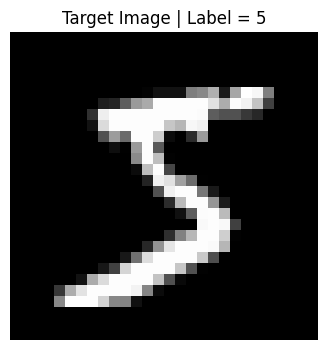

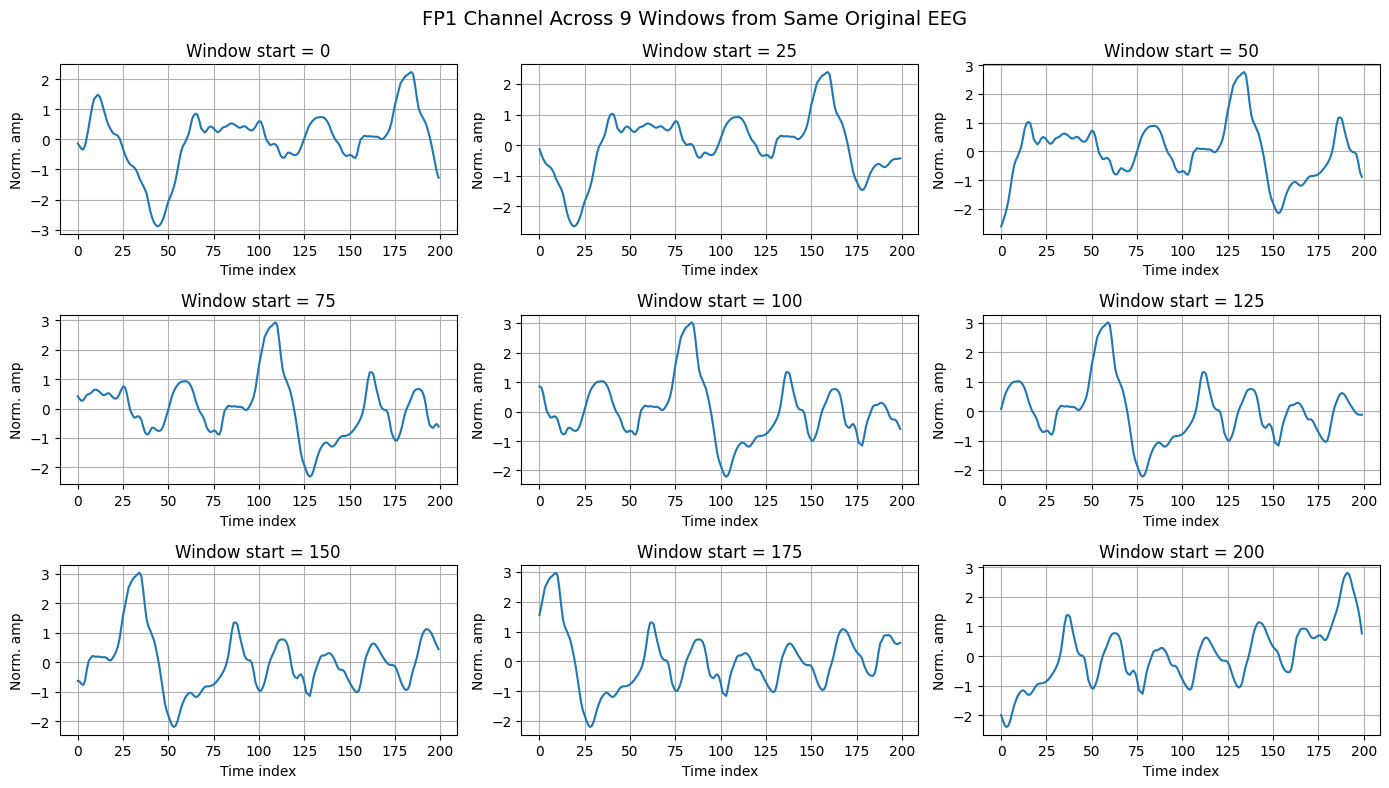

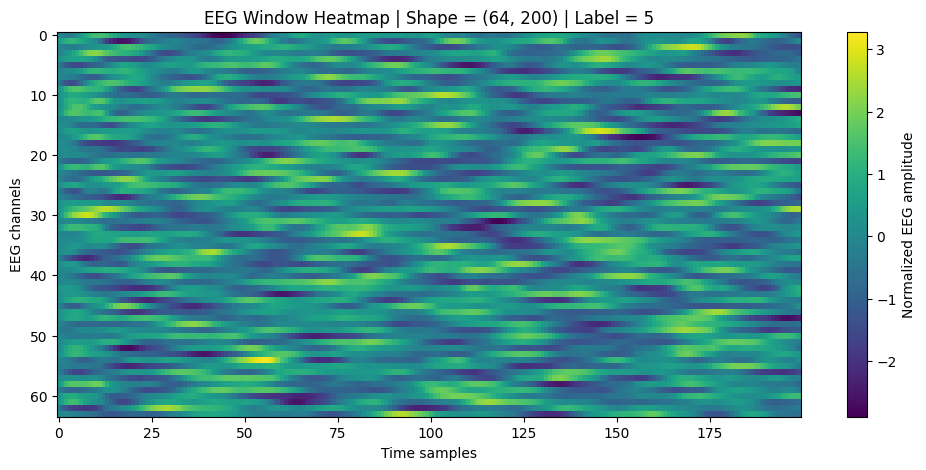

In [7]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import os

# ==============================
# CELL 7: Leakage check and window visualization
# ==============================

H5_SAVE_PATH = "/kaggle/working/mindbig_processed/mindbig_64ch_windowed_200_stride25.h5"

print("Using HDF5 file:")
print(H5_SAVE_PATH)

with h5py.File(H5_SAVE_PATH, "r") as h5:
    
    print("\n========== BASIC SHAPE CHECK ==========")
    for split in ["train", "val", "test"]:
        print(f"\nSplit: {split}")
        print("EEG shape             :", h5[split]["eeg"].shape)
        print("Image shape           :", h5[split]["image"].shape)
        print("Label shape           :", h5[split]["label"].shape)
        print("Original index shape  :", h5[split]["original_valid_index"].shape)
        print("Window start shape    :", h5[split]["window_start"].shape)

    # ==============================
    # Leakage check
    # ==============================
    train_original_ids = set(h5["train"]["original_valid_index"][:])
    val_original_ids   = set(h5["val"]["original_valid_index"][:])
    test_original_ids  = set(h5["test"]["original_valid_index"][:])

    train_val_overlap = train_original_ids.intersection(val_original_ids)
    train_test_overlap = train_original_ids.intersection(test_original_ids)
    val_test_overlap = val_original_ids.intersection(test_original_ids)

    print("\n========== DATA LEAKAGE CHECK ==========")
    print("Train unique original samples:", len(train_original_ids))
    print("Val unique original samples  :", len(val_original_ids))
    print("Test unique original samples :", len(test_original_ids))

    print("\nTrain-Val overlap :", len(train_val_overlap))
    print("Train-Test overlap:", len(train_test_overlap))
    print("Val-Test overlap  :", len(val_test_overlap))

    if len(train_val_overlap) == 0 and len(train_test_overlap) == 0 and len(val_test_overlap) == 0:
        print("\nResult: No leakage detected. Split is correct.")
    else:
        print("\nWarning: Leakage detected. Need to fix split.")

    # ==============================
    # Window start distribution check
    # ==============================
    print("\n========== WINDOW START CHECK ==========")
    for split in ["train", "val", "test"]:
        starts = h5[split]["window_start"][:]
        print(f"\n{split} window start distribution:")
        print(dict(sorted(Counter(starts).items())))

    # ==============================
    # Visualize one original sample's 9 windows
    # ==============================
    split = "train"

    original_ids = h5[split]["original_valid_index"][:]
    first_original_id = original_ids[0]

    same_original_positions = np.where(original_ids == first_original_id)[0]

    eeg_windows = h5[split]["eeg"][same_original_positions]
    images = h5[split]["image"][same_original_positions]
    labels = h5[split]["label"][same_original_positions]
    starts = h5[split]["window_start"][same_original_positions]

    print("\n========== ONE ORIGINAL SAMPLE WINDOW CHECK ==========")
    print("Selected split:", split)
    print("Original valid index:", first_original_id)
    print("Number of windows found:", len(same_original_positions))
    print("Window starts:", starts.tolist())
    print("Labels:", labels.tolist())

    # Target image
    plt.figure(figsize=(4, 4))
    plt.imshow(images[0], cmap="gray")
    plt.title(f"Target Image | Label = {labels[0]}")
    plt.axis("off")
    plt.show()

    # Plot FP1 channel from all 9 windows
    plt.figure(figsize=(14, 8))

    for i in range(len(eeg_windows)):
        plt.subplot(3, 3, i + 1)
        plt.plot(eeg_windows[i, 0])
        plt.title(f"Window start = {starts[i]}")
        plt.xlabel("Time index")
        plt.ylabel("Norm. amp")
        plt.grid(True)

    plt.suptitle("FP1 Channel Across 9 Windows from Same Original EEG", fontsize=14)
    plt.tight_layout()
    plt.show()

    # EEG heatmap for first window
    plt.figure(figsize=(12, 5))
    plt.imshow(eeg_windows[0], aspect="auto", cmap="viridis")
    plt.colorbar(label="Normalized EEG amplitude")
    plt.title(f"EEG Window Heatmap | Shape = {eeg_windows[0].shape} | Label = {labels[0]}")
    plt.xlabel("Time samples")
    plt.ylabel("EEG channels")
    plt.show()

Using device: cuda

========== DATASET SIZE ==========
Train dataset: 7344
Val dataset  : 1575
Test dataset : 1575

========== ONE BATCH SHAPE ==========
EEG batch shape  : torch.Size([32, 1, 64, 200])
Image batch shape: torch.Size([32, 1, 28, 28])
Label batch shape: torch.Size([32])

========== VALUE RANGE CHECK ==========
EEG min/max  : -3.757734537124634 3.439908266067505
Image min/max: -1.0 1.0

First batch labels:
[1, 3, 5, 2, 3, 3, 7, 0, 2, 1, 7, 7, 7, 8, 8, 7, 1, 6, 8, 7, 5, 9, 4, 2, 5, 9, 7, 6, 4, 0, 7, 1]

First batch original ids:
tensor([1033, 1024,  417, 1015,  911,  183,  649,   79,  849,  637])

First batch window starts:
tensor([ 50,   0, 100,  25, 125, 175,  25, 175,  25, 100])


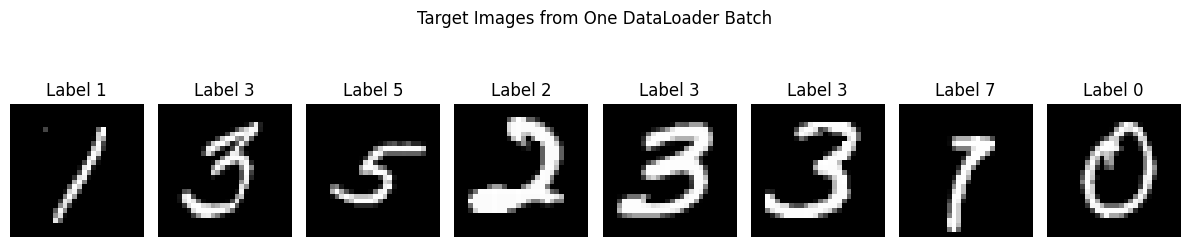

In [8]:
import h5py
import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np

# ==============================
# CELL 8: PyTorch Dataset and DataLoader
# ==============================

H5_SAVE_PATH = "/kaggle/working/mindbig_processed/mindbig_64ch_windowed_200_stride25.h5"

BATCH_SIZE = 32

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


class MindBigWindowedDataset(Dataset):
    def __init__(self, h5_path, split="train", image_range="-1_to_1"):
        """
        h5_path: saved windowed HDF5 file
        split: train / val / test

        image_range:
            "-1_to_1" -> GAN training-এর জন্য ভালো, generator শেষে tanh use করলে
            "0_to_1"  -> normal reconstruction loss/visualization-এর জন্য
        """
        self.h5_path = h5_path
        self.split = split
        self.image_range = image_range
        self.h5 = None

        with h5py.File(self.h5_path, "r") as h5:
            self.length = h5[self.split]["label"].shape[0]

    def __len__(self):
        return self.length

    def _open_h5(self):
        if self.h5 is None:
            self.h5 = h5py.File(self.h5_path, "r")
        return self.h5

    def __getitem__(self, idx):
        h5 = self._open_h5()

        eeg = h5[self.split]["eeg"][idx].astype(np.float32)       # (64, 200)
        image = h5[self.split]["image"][idx].astype(np.float32)   # (28, 28)
        label = int(h5[self.split]["label"][idx])

        original_id = int(h5[self.split]["original_valid_index"][idx])
        window_start = int(h5[self.split]["window_start"][idx])

        # EEG: (64, 200) -> (1, 64, 200)
        eeg = torch.tensor(eeg, dtype=torch.float32).unsqueeze(0)

        # Image: 0-255 -> 0-1
        image = torch.tensor(image, dtype=torch.float32) / 255.0

        # GAN-এর জন্য image target -1 to 1 range-এ রাখছি
        if self.image_range == "-1_to_1":
            image = image * 2.0 - 1.0

        # Image: (28, 28) -> (1, 28, 28)
        image = image.unsqueeze(0)

        label = torch.tensor(label, dtype=torch.long)

        return {
            "eeg": eeg,
            "image": image,
            "label": label,
            "original_id": original_id,
            "window_start": window_start
        }


train_dataset = MindBigWindowedDataset(
    H5_SAVE_PATH,
    split="train",
    image_range="-1_to_1"
)

val_dataset = MindBigWindowedDataset(
    H5_SAVE_PATH,
    split="val",
    image_range="-1_to_1"
)

test_dataset = MindBigWindowedDataset(
    H5_SAVE_PATH,
    split="test",
    image_range="-1_to_1"
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True if device.type == "cuda" else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True if device.type == "cuda" else False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True if device.type == "cuda" else False
)

print("\n========== DATASET SIZE ==========")
print("Train dataset:", len(train_dataset))
print("Val dataset  :", len(val_dataset))
print("Test dataset :", len(test_dataset))

batch = next(iter(train_loader))

eeg_batch = batch["eeg"]
image_batch = batch["image"]
label_batch = batch["label"]

print("\n========== ONE BATCH SHAPE ==========")
print("EEG batch shape  :", eeg_batch.shape)
print("Image batch shape:", image_batch.shape)
print("Label batch shape:", label_batch.shape)

print("\n========== VALUE RANGE CHECK ==========")
print("EEG min/max  :", eeg_batch.min().item(), eeg_batch.max().item())
print("Image min/max:", image_batch.min().item(), image_batch.max().item())

print("\nFirst batch labels:")
print(label_batch.tolist())

print("\nFirst batch original ids:")
print(batch["original_id"][:10])

print("\nFirst batch window starts:")
print(batch["window_start"][:10])


# Visualize few target images from batch
num_show = 8

plt.figure(figsize=(12, 3))

for i in range(num_show):
    img = image_batch[i].squeeze(0).numpy()

    # convert from [-1, 1] back to [0, 1] for visualization
    img = (img + 1.0) / 2.0

    plt.subplot(1, num_show, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(f"Label {label_batch[i].item()}")
    plt.axis("off")

plt.suptitle("Target Images from One DataLoader Batch")
plt.tight_layout()
plt.show()

========== MODEL INFO ==========
Model name       : SimpleEEG2ImageGenerator
Total parameters : 2393985
Trainable params : 2393985

========== FORWARD PASS CHECK ==========
Input EEG shape       : torch.Size([32, 1, 64, 200])
Target image shape    : torch.Size([32, 1, 28, 28])
Generated image shape : torch.Size([32, 1, 28, 28])

========== VALUE RANGE CHECK ==========
Target image min/max   : -1.0 1.0
Generated image min/max: 0.0021110556554049253 0.019877538084983826


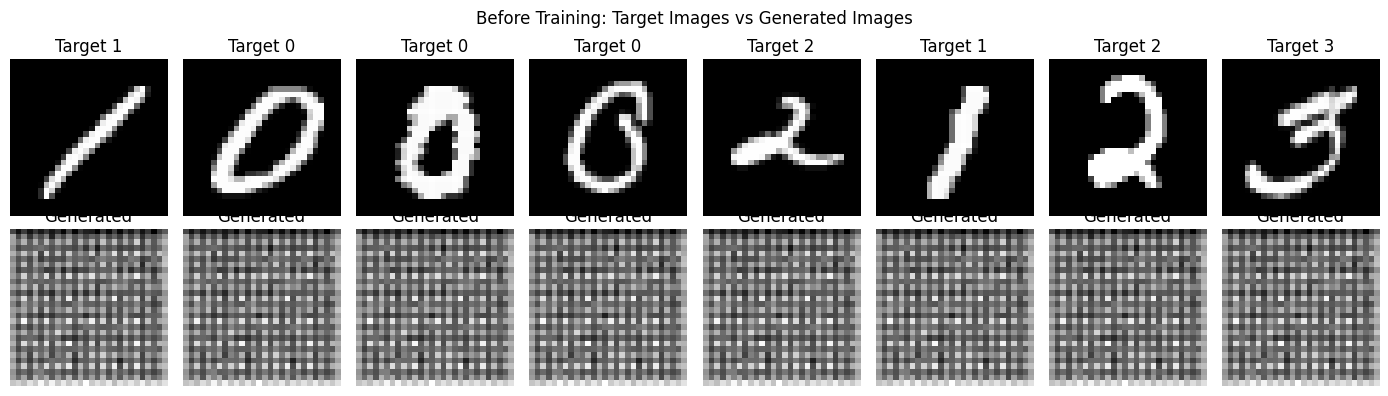

In [9]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ==============================
# CELL 9: Simple baseline EEG-to-image generator
# ==============================

class SimpleEEG2ImageGenerator(nn.Module):
    def __init__(self, latent_dim=256):
        super(SimpleEEG2ImageGenerator, self).__init__()

        # ------------------------------
        # EEG Encoder
        # ------------------------------
        # Input: (B, 1, 64, 200)
        # এখানে CNN encoder EEG matrix থেকে feature বের করবে.
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),   # (B, 32, 32, 100)
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # (B, 64, 16, 50)
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1), # (B, 128, 8, 25)
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.AdaptiveAvgPool2d((4, 4))                            # (B, 128, 4, 4)
        )

        # Flatten feature -> latent vector
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, latent_dim),
            nn.ReLU(inplace=True),

            nn.Linear(latent_dim, 128 * 7 * 7),
            nn.ReLU(inplace=True)
        )

        # ------------------------------
        # Image Decoder
        # ------------------------------
        # Latent feature থেকে image generate করবে.
        # Output target: (B, 1, 28, 28)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # (B, 64, 14, 14)
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),   # (B, 32, 28, 28)
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 1, kernel_size=3, stride=1, padding=1),             # (B, 1, 28, 28)
            nn.Tanh()                                                         # output range: -1 to 1
        )

    def forward(self, eeg):
        x = self.encoder(eeg)
        x = self.fc(x)
        x = x.view(-1, 128, 7, 7)
        out = self.decoder(x)
        return out


# Create model
baseline_generator = SimpleEEG2ImageGenerator(latent_dim=256).to(device)

# Count parameters
total_params = sum(p.numel() for p in baseline_generator.parameters())
trainable_params = sum(p.numel() for p in baseline_generator.parameters() if p.requires_grad)

print("========== MODEL INFO ==========")
print("Model name       : SimpleEEG2ImageGenerator")
print("Total parameters :", total_params)
print("Trainable params :", trainable_params)

# Take one batch
batch = next(iter(train_loader))

eeg_batch = batch["eeg"].to(device)
target_images = batch["image"].to(device)
labels = batch["label"]

# Forward pass
baseline_generator.eval()
with torch.no_grad():
    generated_images = baseline_generator(eeg_batch)

print("\n========== FORWARD PASS CHECK ==========")
print("Input EEG shape       :", eeg_batch.shape)
print("Target image shape    :", target_images.shape)
print("Generated image shape :", generated_images.shape)

print("\n========== VALUE RANGE CHECK ==========")
print("Target image min/max   :", target_images.min().item(), target_images.max().item())
print("Generated image min/max:", generated_images.min().item(), generated_images.max().item())

# Visualize target vs generated before training
num_show = 8

plt.figure(figsize=(14, 4))

for i in range(num_show):
    # target image: [-1,1] -> [0,1]
    target = target_images[i].detach().cpu().squeeze(0)
    target = (target + 1.0) / 2.0

    gen = generated_images[i].detach().cpu().squeeze(0)
    gen = (gen + 1.0) / 2.0

    plt.subplot(2, num_show, i + 1)
    plt.imshow(target, cmap="gray")
    plt.title(f"Target {labels[i].item()}")
    plt.axis("off")

    plt.subplot(2, num_show, num_show + i + 1)
    plt.imshow(gen, cmap="gray")
    plt.title("Generated")
    plt.axis("off")

plt.suptitle("Before Training: Target Images vs Generated Images")
plt.tight_layout()
plt.show()

========== TRAINING STARTED ==========
Epochs: 20
Learning rate: 0.0001
Loss: L1 reconstruction loss
Checkpoint dir: /kaggle/working/mindbig_checkpoints


Epoch 1/20 [Train]:   0%|          | 0/230 [00:00<?, ?it/s]

Epoch 1/20 [Val]:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch [01/20] Train L1: 0.39160 | Val L1: 0.27708
Best model saved at epoch 1 | Best Val L1: 0.27708


Epoch 2/20 [Train]:   0%|          | 0/230 [00:00<?, ?it/s]

...

Epoch 19/20 [Val]:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch [19/20] Train L1: 0.15266 | Val L1: 0.27045


Epoch 20/20 [Train]:   0%|          | 0/230 [00:00<?, ?it/s]

Epoch 20/20 [Val]:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch [20/20] Train L1: 0.14695 | Val L1: 0.27172

========== TRAINING FINISHED ==========
Best Val L1: 0.24412081862252857
Best model saved at: /kaggle/working/mindbig_checkpoints/best_simple_eeg2image_generator.pth
Last model saved at: /kaggle/working/mindbig_checkpoints/last_simple_eeg2image_generator.pth


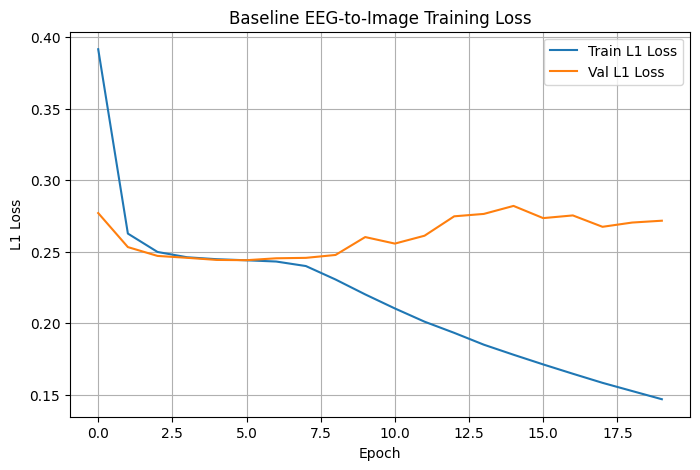

In [10]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# ==============================
# CELL 10: Train simple baseline EEG-to-image generator
# ==============================

CHECKPOINT_DIR = "/kaggle/working/mindbig_checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

BEST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, "best_simple_eeg2image_generator.pth")
LAST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, "last_simple_eeg2image_generator.pth")

NUM_EPOCHS = 20
LEARNING_RATE = 1e-4

# Loss function
criterion_l1 = nn.L1Loss()

# Optimizer
optimizer_G = optim.Adam(
    baseline_generator.parameters(),
    lr=LEARNING_RATE,
    betas=(0.5, 0.999)
)

best_val_loss = float("inf")

train_losses = []
val_losses = []

print("========== TRAINING STARTED ==========")
print("Epochs:", NUM_EPOCHS)
print("Learning rate:", LEARNING_RATE)
print("Loss: L1 reconstruction loss")
print("Checkpoint dir:", CHECKPOINT_DIR)


for epoch in range(1, NUM_EPOCHS + 1):
    
    # ==============================
    # Training phase
    # ==============================
    baseline_generator.train()
    running_train_loss = 0.0
    
    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS} [Train]")
    
    for batch in train_pbar:
        eeg = batch["eeg"].to(device)
        target_img = batch["image"].to(device)
        
        optimizer_G.zero_grad()
        
        generated_img = baseline_generator(eeg)
        
        loss_l1 = criterion_l1(generated_img, target_img)
        
        loss_l1.backward()
        optimizer_G.step()
        
        running_train_loss += loss_l1.item() * eeg.size(0)
        
        train_pbar.set_postfix({
            "L1 Loss": f"{loss_l1.item():.4f}"
        })
    
    epoch_train_loss = running_train_loss / len(train_dataset)
    train_losses.append(epoch_train_loss)
    
    
    # ==============================
    # Validation phase
    # ==============================
    baseline_generator.eval()
    running_val_loss = 0.0
    
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS} [Val]"):
            eeg = batch["eeg"].to(device)
            target_img = batch["image"].to(device)
            
            generated_img = baseline_generator(eeg)
            
            loss_l1 = criterion_l1(generated_img, target_img)
            running_val_loss += loss_l1.item() * eeg.size(0)
    
    epoch_val_loss = running_val_loss / len(val_dataset)
    val_losses.append(epoch_val_loss)
    
    
    print(
        f"Epoch [{epoch:02d}/{NUM_EPOCHS}] "
        f"Train L1: {epoch_train_loss:.5f} | "
        f"Val L1: {epoch_val_loss:.5f}"
    )
    
    
    # ==============================
    # Save best checkpoint
    # ==============================
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        
        torch.save({
            "epoch": epoch,
            "model_state_dict": baseline_generator.state_dict(),
            "optimizer_state_dict": optimizer_G.state_dict(),
            "best_val_loss": best_val_loss,
            "train_losses": train_losses,
            "val_losses": val_losses
        }, BEST_MODEL_PATH)
        
        print(f"Best model saved at epoch {epoch} | Best Val L1: {best_val_loss:.5f}")
    
    
    # Save last checkpoint
    torch.save({
        "epoch": epoch,
        "model_state_dict": baseline_generator.state_dict(),
        "optimizer_state_dict": optimizer_G.state_dict(),
        "best_val_loss": best_val_loss,
        "train_losses": train_losses,
        "val_losses": val_losses
    }, LAST_MODEL_PATH)


print("\n========== TRAINING FINISHED ==========")
print("Best Val L1:", best_val_loss)
print("Best model saved at:", BEST_MODEL_PATH)
print("Last model saved at:", LAST_MODEL_PATH)


# ==============================
# Plot training and validation loss
# ==============================

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train L1 Loss")
plt.plot(val_losses, label="Val L1 Loss")
plt.xlabel("Epoch")
plt.ylabel("L1 Loss")
plt.title("Baseline EEG-to-Image Training Loss")
plt.legend()
plt.grid(True)
plt.show()

Loading best checkpoint from:
/kaggle/working/mindbig_checkpoints/best_simple_eeg2image_generator.pth

========== CHECKPOINT INFO ==========
Best epoch    : 6
Best Val L1   : 0.24412081862252857

========== ONE VAL BATCH CHECK ==========
EEG shape       : torch.Size([32, 1, 64, 200])
Target shape    : torch.Size([32, 1, 28, 28])
Generated shape : torch.Size([32, 1, 28, 28])
Batch L1 loss   : 0.26731258630752563
Generated min/max: -0.9995493292808533 0.3667624592781067
Target min/max   : -1.0 1.0


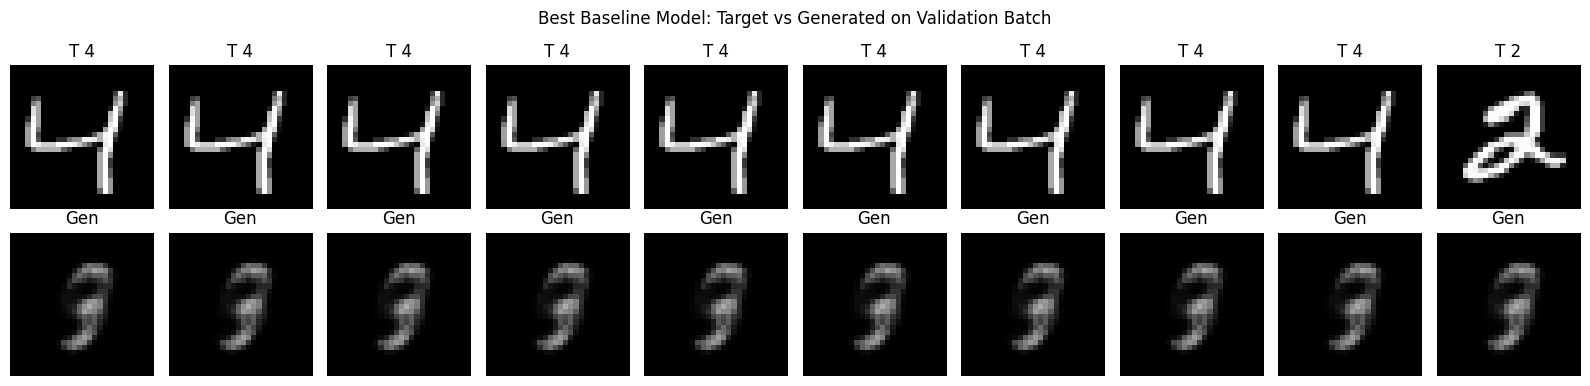

In [11]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import os

# ==============================
# CELL 11: Load best baseline checkpoint and visualize output
# ==============================

BEST_MODEL_PATH = "/kaggle/working/mindbig_checkpoints/best_simple_eeg2image_generator.pth"

print("Loading best checkpoint from:")
print(BEST_MODEL_PATH)

checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)

baseline_generator.load_state_dict(checkpoint["model_state_dict"])
baseline_generator = baseline_generator.to(device)
baseline_generator.eval()

print("\n========== CHECKPOINT INFO ==========")
print("Best epoch    :", checkpoint["epoch"])
print("Best Val L1   :", checkpoint["best_val_loss"])


# Take one validation batch
batch = next(iter(val_loader))

eeg = batch["eeg"].to(device)
target = batch["image"].to(device)
labels = batch["label"]

with torch.no_grad():
    generated = baseline_generator(eeg)

# L1 check on this batch
batch_l1 = nn.L1Loss()(generated, target).item()

print("\n========== ONE VAL BATCH CHECK ==========")
print("EEG shape       :", eeg.shape)
print("Target shape    :", target.shape)
print("Generated shape :", generated.shape)
print("Batch L1 loss   :", batch_l1)

print("Generated min/max:", generated.min().item(), generated.max().item())
print("Target min/max   :", target.min().item(), target.max().item())


# Visualize target vs generated
num_show = 10

plt.figure(figsize=(16, 4))

for i in range(num_show):
    target_img = target[i].detach().cpu().squeeze(0)
    gen_img = generated[i].detach().cpu().squeeze(0)

    # Convert [-1, 1] to [0, 1]
    target_img = (target_img + 1.0) / 2.0
    gen_img = (gen_img + 1.0) / 2.0

    plt.subplot(2, num_show, i + 1)
    plt.imshow(target_img, cmap="gray", vmin=0, vmax=1)
    plt.title(f"T {labels[i].item()}")
    plt.axis("off")

    plt.subplot(2, num_show, num_show + i + 1)
    plt.imshow(gen_img, cmap="gray", vmin=0, vmax=1)
    plt.title("Gen")
    plt.axis("off")

plt.suptitle("Best Baseline Model: Target vs Generated on Validation Batch")
plt.tight_layout()
plt.show()

/tmp/ipykernel_23/2163210221.py:108: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)


========== MODEL INFO ==========
Generator     : ViTEEGGenerator
G total params: 1241025
G trainable   : 1241025

Discriminator : ConditionalUNetDiscriminator
D total params: 2552265
D trainable   : 2552265

========== FORWARD PASS CHECK ==========
EEG input shape      : torch.Size([32, 1, 64, 200])
Real image shape     : torch.Size([32, 1, 28, 28])
Generated image shape: torch.Size([32, 1, 28, 28])
Real score shape     : torch.Size([32, 1, 28, 28])
Fake score shape     : torch.Size([32, 1, 28, 28])

========== VALUE RANGE CHECK ==========
Real image min/max   : -1.0 1.0
Fake image min/max   : -0.0321858674287796 -0.005762833636254072
Real score min/max   : 0.025404643267393112 0.047904517501592636
Fake score min/max   : 0.02559259906411171 0.046272531151771545


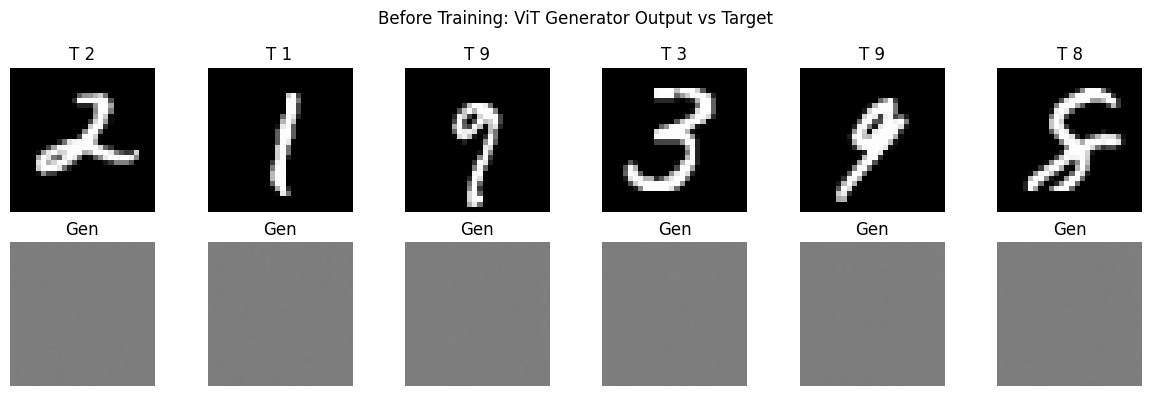

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# ==============================
# CELL 12: ViT Generator + Conditional U-Net Discriminator
# ==============================

# ---------------------------------------------------
# Helper blocks
# ---------------------------------------------------
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(out_ch, out_ch, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.2, inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class DownBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.2, inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class UpBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.ConvTranspose2d(in_ch, out_ch, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


# ---------------------------------------------------
# ViT-based EEG Generator
# ---------------------------------------------------
class ViTEEGGenerator(nn.Module):
    def __init__(
        self,
        input_channels=1,
        eeg_height=64,
        eeg_width=200,
        patch_size=(8, 20),
        embed_dim=128,
        depth=4,
        num_heads=8,
        mlp_ratio=4.0,
        dropout=0.1
    ):
        super().__init__()

        self.eeg_height = eeg_height
        self.eeg_width = eeg_width
        self.patch_h, self.patch_w = patch_size

        assert eeg_height % self.patch_h == 0, "EEG height must be divisible by patch height"
        assert eeg_width % self.patch_w == 0, "EEG width must be divisible by patch width"

        self.grid_h = eeg_height // self.patch_h   # 64/8 = 8
        self.grid_w = eeg_width // self.patch_w    # 200/20 = 10
        self.num_patches = self.grid_h * self.grid_w

        # Patch embedding:
        # EEG (1,64,200) -> patches -> embedding tokens
        self.patch_embed = nn.Conv2d(
            input_channels,
            embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )  # output: (B, embed_dim, 8, 10)

        # Positional embedding
        self.pos_embed = nn.Parameter(torch.randn(1, self.num_patches, embed_dim) * 0.02)
        self.dropout = nn.Dropout(dropout)

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=int(embed_dim * mlp_ratio),
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)

        # CNN decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(embed_dim, 128, kernel_size=4, stride=2, padding=1),  # (8,10) -> (16,20)
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),         # (16,20) -> (32,40)
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True)
        )

        self.final_conv = nn.Sequential(
            nn.Conv2d(32, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 1, kernel_size=3, stride=1, padding=1),
            nn.Tanh()
        )

    def forward(self, eeg):
        # eeg: (B, 1, 64, 200)

        # Patch embedding
        x = self.patch_embed(eeg)                 # (B, embed_dim, 8, 10)

        # Flatten to tokens
        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)         # (B, num_patches, embed_dim)

        # Add position embedding
        x = x + self.pos_embed
        x = self.dropout(x)

        # Transformer
        x = self.transformer(x)                  # (B, num_patches, embed_dim)

        # Back to 2D feature map
        x = x.transpose(1, 2).reshape(B, C, H, W)   # (B, embed_dim, 8, 10)

        # Decode to image
        x = self.decoder(x)                      # (B, 32, 32, 40)

        # Resize to exactly 28x28
        x = F.interpolate(x, size=(28, 28), mode="bilinear", align_corners=False)

        out = self.final_conv(x)                 # (B, 1, 28, 28)
        return out


# ---------------------------------------------------
# Conditional U-Net style Discriminator
# ---------------------------------------------------
class ConditionalUNetDiscriminator(nn.Module):
    def __init__(self, eeg_cond_channels=8, base_ch=32):
        super().__init__()

        # EEG condition projector
        # EEG -> small feature map -> resized to 28x28
        self.eeg_projector = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),   # (64,200) -> (32,100)
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(16, eeg_cond_channels, kernel_size=3, stride=2, padding=1),  # -> (16,50)
            nn.LeakyReLU(0.2, inplace=True)
        )

        # Input will be [image + eeg_condition]
        in_ch = 1 + eeg_cond_channels

        # Encoder
        self.enc1 = ConvBlock(in_ch, base_ch)          # 28x28
        self.down1 = DownBlock(base_ch, base_ch * 2)   # 14x14
        self.enc2 = ConvBlock(base_ch * 2, base_ch * 2)

        self.down2 = DownBlock(base_ch * 2, base_ch * 4)  # 7x7
        self.enc3 = ConvBlock(base_ch * 4, base_ch * 4)

        # Bottleneck
        self.bottleneck = ConvBlock(base_ch * 4, base_ch * 8)

        # Decoder
        self.up2 = UpBlock(base_ch * 8, base_ch * 4)   # 7 -> 14
        self.dec2 = ConvBlock(base_ch * 4 + base_ch * 2, base_ch * 4)

        self.up1 = UpBlock(base_ch * 4, base_ch * 2)   # 14 -> 28
        self.dec1 = ConvBlock(base_ch * 2 + base_ch, base_ch * 2)

        # Final patch realism map
        self.final = nn.Conv2d(base_ch * 2, 1, kernel_size=3, stride=1, padding=1)

    def forward(self, eeg, img):
        # eeg: (B,1,64,200)
        # img: (B,1,28,28)

        cond = self.eeg_projector(eeg)  # (B, eeg_cond_channels, 16, 50)
        cond = F.interpolate(cond, size=(28, 28), mode="bilinear", align_corners=False)

        x = torch.cat([img, cond], dim=1)  # (B, 1+cond_ch, 28, 28)

        e1 = self.enc1(x)             # (B, base, 28,28)
        e2 = self.enc2(self.down1(e1)) # (B, 2base, 14,14)
        e3 = self.enc3(self.down2(e2)) # (B, 4base, 7,7)

        b = self.bottleneck(e3)       # (B, 8base, 7,7)

        u2 = self.up2(b)              # (B, 4base, 14,14)
        d2 = self.dec2(torch.cat([u2, e2], dim=1))

        u1 = self.up1(d2)             # (B, 2base, 28,28)
        d1 = self.dec1(torch.cat([u1, e1], dim=1))

        out = self.final(d1)          # (B, 1, 28, 28)
        return out


# ---------------------------------------------------
# Instantiate models
# ---------------------------------------------------
vit_generator = ViTEEGGenerator(
    patch_size=(8, 20),
    embed_dim=128,
    depth=4,
    num_heads=8,
    mlp_ratio=4.0,
    dropout=0.1
).to(device)

unet_discriminator = ConditionalUNetDiscriminator(
    eeg_cond_channels=8,
    base_ch=32
).to(device)


def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


g_total, g_trainable = count_params(vit_generator)
d_total, d_trainable = count_params(unet_discriminator)

print("========== MODEL INFO ==========")
print("Generator     : ViTEEGGenerator")
print("G total params:", g_total)
print("G trainable   :", g_trainable)

print("\nDiscriminator : ConditionalUNetDiscriminator")
print("D total params:", d_total)
print("D trainable   :", d_trainable)


# ---------------------------------------------------
# Forward pass check
# ---------------------------------------------------
batch = next(iter(train_loader))

eeg = batch["eeg"].to(device)         # (B,1,64,200)
real_img = batch["image"].to(device)  # (B,1,28,28)

vit_generator.eval()
unet_discriminator.eval()

with torch.no_grad():
    fake_img = vit_generator(eeg)

    real_score = unet_discriminator(eeg, real_img)
    fake_score = unet_discriminator(eeg, fake_img)

print("\n========== FORWARD PASS CHECK ==========")
print("EEG input shape      :", eeg.shape)
print("Real image shape     :", real_img.shape)
print("Generated image shape:", fake_img.shape)
print("Real score shape     :", real_score.shape)
print("Fake score shape     :", fake_score.shape)

print("\n========== VALUE RANGE CHECK ==========")
print("Real image min/max   :", real_img.min().item(), real_img.max().item())
print("Fake image min/max   :", fake_img.min().item(), fake_img.max().item())
print("Real score min/max   :", real_score.min().item(), real_score.max().item())
print("Fake score min/max   :", fake_score.min().item(), fake_score.max().item())


# ---------------------------------------------------
# Visualize target vs generated before training
# ---------------------------------------------------
num_show = 6

plt.figure(figsize=(12, 4))

for i in range(num_show):
    target = real_img[i].detach().cpu().squeeze(0)
    gen = fake_img[i].detach().cpu().squeeze(0)

    # [-1,1] -> [0,1]
    target = (target + 1.0) / 2.0
    gen = (gen + 1.0) / 2.0

    plt.subplot(2, num_show, i + 1)
    plt.imshow(target, cmap="gray", vmin=0, vmax=1)
    plt.title(f"T {batch['label'][i].item()}")
    plt.axis("off")

    plt.subplot(2, num_show, num_show + i + 1)
    plt.imshow(gen, cmap="gray", vmin=0, vmax=1)
    plt.title("Gen")
    plt.axis("off")

plt.suptitle("Before Training: ViT Generator Output vs Target")
plt.tight_layout()
plt.show()

========== GAN TRAINING STARTED ==========
Generator      : ViT-based EEG Generator
Discriminator  : Conditional U-Net Discriminator
Epochs         : 20
LR_G           : 0.0001
LR_D           : 5e-05
LAMBDA_L1      : 100.0
LAMBDA_ADV     : 1.0
Checkpoint dir : /kaggle/working/mindbig_gan_checkpoints


Epoch 1/20 [GAN Train]:   0%|          | 0/230 [00:00<?, ?it/s]

Epoch 1/20 [Val]:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch [01/20] G Loss: 34.6221 | D Loss: 0.4085 | Train L1: 0.33249 | Train Adv: 1.37273 | Val L1: 0.24847
Best GAN checkpoint saved at epoch 1 | Best Val L1: 0.24847


Epoch 2/20 [GAN Train]:   0%|          | 0/230 [00:00<?, ?it/s]

...

Epoch 19/20 [Val]:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch [19/20] G Loss: 28.5617 | D Loss: 0.1978 | Train L1: 0.22739 | Train Adv: 5.82281 | Val L1: 0.25186


Epoch 20/20 [GAN Train]:   0%|          | 0/230 [00:00<?, ?it/s]

Epoch 20/20 [Val]:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch [20/20] G Loss: 28.6937 | D Loss: 0.1633 | Train L1: 0.22536 | Train Adv: 6.15800 | Val L1: 0.25299

========== GAN TRAINING FINISHED ==========
Best Val L1: 0.24385513570573594
Best Generator saved at: /kaggle/working/mindbig_gan_checkpoints/best_vit_generator.pth
Best Discriminator saved at: /kaggle/working/mindbig_gan_checkpoints/best_unet_discriminator.pth


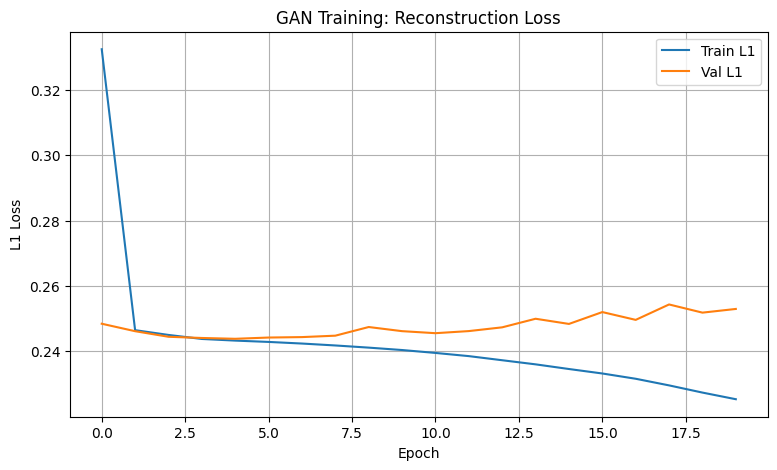

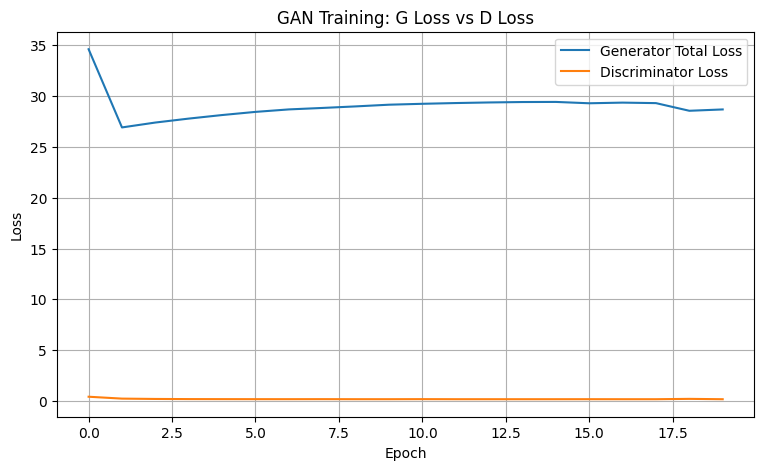

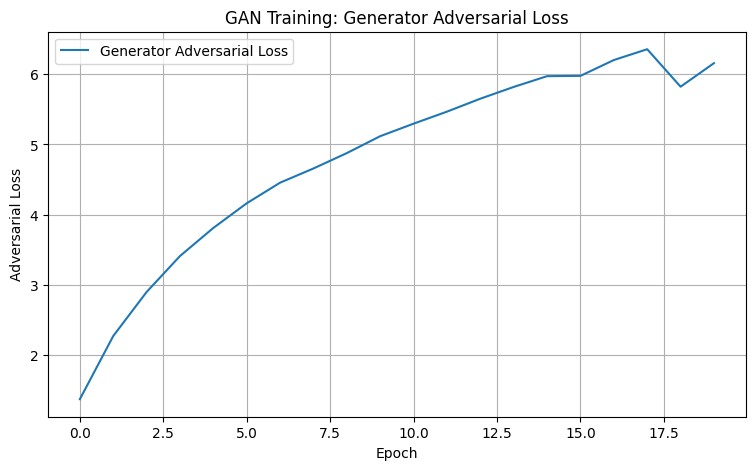

In [13]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import numpy as np
import gc

# ==============================
# CELL 13: GAN Training
# ViT Generator + Conditional U-Net Discriminator
# ==============================

# Free old baseline model memory if it exists
try:
    del baseline_generator
    torch.cuda.empty_cache()
    gc.collect()
except:
    pass

GAN_CHECKPOINT_DIR = "/kaggle/working/mindbig_gan_checkpoints"
os.makedirs(GAN_CHECKPOINT_DIR, exist_ok=True)

BEST_G_PATH = os.path.join(GAN_CHECKPOINT_DIR, "best_vit_generator.pth")
BEST_D_PATH = os.path.join(GAN_CHECKPOINT_DIR, "best_unet_discriminator.pth")
LAST_G_PATH = os.path.join(GAN_CHECKPOINT_DIR, "last_vit_generator.pth")
LAST_D_PATH = os.path.join(GAN_CHECKPOINT_DIR, "last_unet_discriminator.pth")

# Training settings
NUM_EPOCHS = 20
LR_G = 1e-4
LR_D = 5e-5

# Loss weights
LAMBDA_L1 = 100.0
LAMBDA_ADV = 1.0

# Loss functions
criterion_adv = nn.BCEWithLogitsLoss()
criterion_l1 = nn.L1Loss()

# Optimizers
optimizer_G = optim.Adam(
    vit_generator.parameters(),
    lr=LR_G,
    betas=(0.5, 0.999)
)

optimizer_D = optim.Adam(
    unet_discriminator.parameters(),
    lr=LR_D,
    betas=(0.5, 0.999)
)

best_val_l1 = float("inf")

history = {
    "train_g_loss": [],
    "train_d_loss": [],
    "train_l1_loss": [],
    "train_adv_loss": [],
    "val_l1_loss": []
}

print("========== GAN TRAINING STARTED ==========")
print("Generator      : ViT-based EEG Generator")
print("Discriminator  : Conditional U-Net Discriminator")
print("Epochs         :", NUM_EPOCHS)
print("LR_G           :", LR_G)
print("LR_D           :", LR_D)
print("LAMBDA_L1      :", LAMBDA_L1)
print("LAMBDA_ADV     :", LAMBDA_ADV)
print("Checkpoint dir :", GAN_CHECKPOINT_DIR)


for epoch in range(1, NUM_EPOCHS + 1):

    vit_generator.train()
    unet_discriminator.train()

    running_g_loss = 0.0
    running_d_loss = 0.0
    running_l1_loss = 0.0
    running_adv_loss = 0.0

    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS} [GAN Train]")

    for batch in train_pbar:
        eeg = batch["eeg"].to(device)
        real_img = batch["image"].to(device)

        batch_size = eeg.size(0)

        # Patch-level labels
        # Discriminator output shape: (B, 1, 28, 28)
        # Real label smoothing: real = 0.9 instead of 1.0
        real_label = torch.full(
            (batch_size, 1, 28, 28),
            0.9,
            device=device
        )

        fake_label = torch.zeros(
            (batch_size, 1, 28, 28),
            device=device
        )

        # ==================================================
        # 1) Train Discriminator
        # ==================================================
        optimizer_D.zero_grad()

        with torch.no_grad():
            fake_img_detached = vit_generator(eeg)

        real_score = unet_discriminator(eeg, real_img)
        fake_score = unet_discriminator(eeg, fake_img_detached.detach())

        d_loss_real = criterion_adv(real_score, real_label)
        d_loss_fake = criterion_adv(fake_score, fake_label)

        d_loss = 0.5 * (d_loss_real + d_loss_fake)

        d_loss.backward()
        torch.nn.utils.clip_grad_norm_(unet_discriminator.parameters(), max_norm=1.0)
        optimizer_D.step()

        # ==================================================
        # 2) Train Generator
        # ==================================================
        optimizer_G.zero_grad()

        fake_img = vit_generator(eeg)
        fake_score_for_g = unet_discriminator(eeg, fake_img)

        # Generator wants discriminator to classify fake as real
        g_adv_loss = criterion_adv(fake_score_for_g, real_label)

        # Reconstruction loss
        g_l1_loss = criterion_l1(fake_img, real_img)

        # Total generator loss
        g_loss = (LAMBDA_ADV * g_adv_loss) + (LAMBDA_L1 * g_l1_loss)

        g_loss.backward()
        torch.nn.utils.clip_grad_norm_(vit_generator.parameters(), max_norm=1.0)
        optimizer_G.step()

        running_g_loss += g_loss.item() * batch_size
        running_d_loss += d_loss.item() * batch_size
        running_l1_loss += g_l1_loss.item() * batch_size
        running_adv_loss += g_adv_loss.item() * batch_size

        train_pbar.set_postfix({
            "G": f"{g_loss.item():.3f}",
            "D": f"{d_loss.item():.3f}",
            "L1": f"{g_l1_loss.item():.4f}",
            "Adv": f"{g_adv_loss.item():.4f}"
        })

    epoch_g_loss = running_g_loss / len(train_dataset)
    epoch_d_loss = running_d_loss / len(train_dataset)
    epoch_l1_loss = running_l1_loss / len(train_dataset)
    epoch_adv_loss = running_adv_loss / len(train_dataset)

    # ==================================================
    # Validation using L1 only
    # ==================================================
    vit_generator.eval()
    val_l1_total = 0.0

    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS} [Val]"):
            eeg = batch["eeg"].to(device)
            real_img = batch["image"].to(device)

            fake_img = vit_generator(eeg)

            val_l1 = criterion_l1(fake_img, real_img)
            val_l1_total += val_l1.item() * eeg.size(0)

    epoch_val_l1 = val_l1_total / len(val_dataset)

    history["train_g_loss"].append(epoch_g_loss)
    history["train_d_loss"].append(epoch_d_loss)
    history["train_l1_loss"].append(epoch_l1_loss)
    history["train_adv_loss"].append(epoch_adv_loss)
    history["val_l1_loss"].append(epoch_val_l1)

    print(
        f"Epoch [{epoch:02d}/{NUM_EPOCHS}] "
        f"G Loss: {epoch_g_loss:.4f} | "
        f"D Loss: {epoch_d_loss:.4f} | "
        f"Train L1: {epoch_l1_loss:.5f} | "
        f"Train Adv: {epoch_adv_loss:.5f} | "
        f"Val L1: {epoch_val_l1:.5f}"
    )

    # Save best model based on validation L1
    if epoch_val_l1 < best_val_l1:
        best_val_l1 = epoch_val_l1

        torch.save({
            "epoch": epoch,
            "model_state_dict": vit_generator.state_dict(),
            "optimizer_state_dict": optimizer_G.state_dict(),
            "best_val_l1": best_val_l1,
            "history": history
        }, BEST_G_PATH)

        torch.save({
            "epoch": epoch,
            "model_state_dict": unet_discriminator.state_dict(),
            "optimizer_state_dict": optimizer_D.state_dict(),
            "best_val_l1": best_val_l1,
            "history": history
        }, BEST_D_PATH)

        print(f"Best GAN checkpoint saved at epoch {epoch} | Best Val L1: {best_val_l1:.5f}")

    # Always save last model
    torch.save({
        "epoch": epoch,
        "model_state_dict": vit_generator.state_dict(),
        "optimizer_state_dict": optimizer_G.state_dict(),
        "best_val_l1": best_val_l1,
        "history": history
    }, LAST_G_PATH)

    torch.save({
        "epoch": epoch,
        "model_state_dict": unet_discriminator.state_dict(),
        "optimizer_state_dict": optimizer_D.state_dict(),
        "best_val_l1": best_val_l1,
        "history": history
    }, LAST_D_PATH)


print("\n========== GAN TRAINING FINISHED ==========")
print("Best Val L1:", best_val_l1)
print("Best Generator saved at:", BEST_G_PATH)
print("Best Discriminator saved at:", BEST_D_PATH)


# ==============================
# Plot training curves
# ==============================

plt.figure(figsize=(9, 5))
plt.plot(history["train_l1_loss"], label="Train L1")
plt.plot(history["val_l1_loss"], label="Val L1")
plt.xlabel("Epoch")
plt.ylabel("L1 Loss")
plt.title("GAN Training: Reconstruction Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(history["train_g_loss"], label="Generator Total Loss")
plt.plot(history["train_d_loss"], label="Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Training: G Loss vs D Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(history["train_adv_loss"], label="Generator Adversarial Loss")
plt.xlabel("Epoch")
plt.ylabel("Adversarial Loss")
plt.title("GAN Training: Generator Adversarial Loss")
plt.legend()
plt.grid(True)
plt.show()

Loading best GAN generator from:
/kaggle/working/mindbig_gan_checkpoints/best_vit_generator.pth

========== BEST GAN CHECKPOINT INFO ==========
Best epoch  : 5
Best Val L1 : 0.24385513570573594

========== ONE VALIDATION BATCH CHECK ==========
EEG shape        : torch.Size([32, 1, 64, 200])
Target shape     : torch.Size([32, 1, 28, 28])
Generated shape  : torch.Size([32, 1, 28, 28])
Batch L1 loss    : 0.26571354269981384

========== VALUE RANGE CHECK ==========
Target min/max   : -1.0 1.0
Generated min/max: -1.0 0.24987168610095978

========== IMAGE STATISTICS ==========
Target mean/std   : 0.13601267337799072 0.30776846408843994
Generated mean/std: 0.04170854389667511 0.11908143758773804


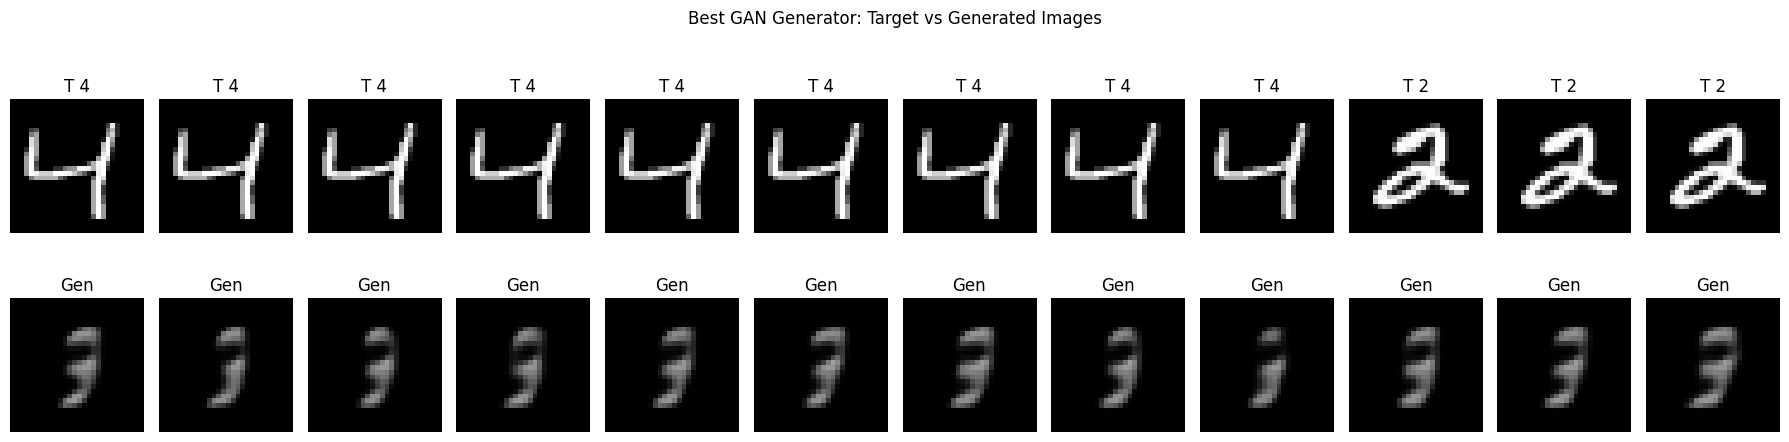

In [14]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import os

# ==============================
# CELL 14: Load best GAN generator and visualize output
# ==============================

BEST_G_PATH = "/kaggle/working/mindbig_gan_checkpoints/best_vit_generator.pth"

print("Loading best GAN generator from:")
print(BEST_G_PATH)

if not os.path.exists(BEST_G_PATH):
    raise FileNotFoundError(f"Checkpoint not found: {BEST_G_PATH}")

checkpoint = torch.load(BEST_G_PATH, map_location=device)

# vit_generator must already be defined from Cell 12
vit_generator.load_state_dict(checkpoint["model_state_dict"])
vit_generator = vit_generator.to(device)
vit_generator.eval()

print("\n========== BEST GAN CHECKPOINT INFO ==========")
print("Best epoch  :", checkpoint["epoch"])
print("Best Val L1 :", checkpoint["best_val_l1"])

# Take one validation batch
batch = next(iter(val_loader))

eeg = batch["eeg"].to(device)
target = batch["image"].to(device)
labels = batch["label"]

with torch.no_grad():
    generated = vit_generator(eeg)

batch_l1 = nn.L1Loss()(generated, target).item()

print("\n========== ONE VALIDATION BATCH CHECK ==========")
print("EEG shape        :", eeg.shape)
print("Target shape     :", target.shape)
print("Generated shape  :", generated.shape)
print("Batch L1 loss    :", batch_l1)

print("\n========== VALUE RANGE CHECK ==========")
print("Target min/max   :", target.min().item(), target.max().item())
print("Generated min/max:", generated.min().item(), generated.max().item())

# Convert from [-1, 1] to [0, 1]
target_01 = (target.detach().cpu() + 1.0) / 2.0
generated_01 = (generated.detach().cpu() + 1.0) / 2.0

print("\n========== IMAGE STATISTICS ==========")
print("Target mean/std   :", target_01.mean().item(), target_01.std().item())
print("Generated mean/std:", generated_01.mean().item(), generated_01.std().item())

# Visualize target vs generated
num_show = 12

plt.figure(figsize=(18, 5))

for i in range(num_show):
    target_img = target_01[i].squeeze(0)
    gen_img = generated_01[i].squeeze(0)

    plt.subplot(2, num_show, i + 1)
    plt.imshow(target_img, cmap="gray", vmin=0, vmax=1)
    plt.title(f"T {labels[i].item()}")
    plt.axis("off")

    plt.subplot(2, num_show, num_show + i + 1)
    plt.imshow(gen_img, cmap="gray", vmin=0, vmax=1)
    plt.title("Gen")
    plt.axis("off")

plt.suptitle("Best GAN Generator: Target vs Generated Images")
plt.tight_layout()
plt.show()

In [15]:
import os
import torch
import torch.nn as nn
import torch.optim as optim

# ==============================
# CELL 15: Fresh generator for pretraining
# ==============================

# Fresh new generator (GAN-trained weights use করবো না)
pretrain_generator = ViTEEGGenerator(
    patch_size=(8, 20),
    embed_dim=128,
    depth=4,
    num_heads=8,
    mlp_ratio=4.0,
    dropout=0.1
).to(device)

# parameter count
total_params = sum(p.numel() for p in pretrain_generator.parameters())
trainable_params = sum(p.numel() for p in pretrain_generator.parameters() if p.requires_grad)

print("========== PRETRAIN GENERATOR INFO ==========")
print("Model              : Fresh ViTEEGGenerator")
print("Total params       :", total_params)
print("Trainable params   :", trainable_params)

# Pretraining checkpoint paths
PRETRAIN_CKPT_DIR = "/kaggle/working/mindbig_pretrain_checkpoints"
os.makedirs(PRETRAIN_CKPT_DIR, exist_ok=True)

PRETRAIN_BEST_PATH = os.path.join(PRETRAIN_CKPT_DIR, "best_pretrained_vit_generator.pth")
PRETRAIN_LAST_PATH = os.path.join(PRETRAIN_CKPT_DIR, "last_pretrained_vit_generator.pth")

print("\nCheckpoint directory:")
print(PRETRAIN_CKPT_DIR)

# Loss and optimizer
pretrain_criterion_l1 = nn.L1Loss()

pretrain_optimizer = optim.Adam(
    pretrain_generator.parameters(),
    lr=1e-4,
    betas=(0.9, 0.999)
)

print("\n========== PRETRAIN SETUP ==========")
print("Loss      : L1Loss")
print("Optimizer : Adam")
print("LR        : 1e-4")

# one forward check
batch = next(iter(train_loader))
eeg = batch["eeg"].to(device)
target = batch["image"].to(device)

pretrain_generator.eval()
with torch.no_grad():
    pred = pretrain_generator(eeg)

print("\n========== FORWARD CHECK ==========")
print("EEG input shape   :", eeg.shape)
print("Target shape      :", target.shape)
print("Predicted shape   :", pred.shape)

print("\nValue range:")
print("Target min/max    :", target.min().item(), target.max().item())
print("Predicted min/max :", pred.min().item(), pred.max().item())

========== PRETRAIN GENERATOR INFO ==========
Model              : Fresh ViTEEGGenerator
Total params       : 1241025
Trainable params   : 1241025

Checkpoint directory:
/kaggle/working/mindbig_pretrain_checkpoints

========== PRETRAIN SETUP ==========
Loss      : L1Loss
Optimizer : Adam
LR        : 1e-4

========== FORWARD CHECK ==========
EEG input shape   : torch.Size([32, 1, 64, 200])
Target shape      : torch.Size([32, 1, 28, 28])
Predicted shape   : torch.Size([32, 1, 28, 28])

Value range:
Target min/max    : -1.0 1.0
Predicted min/max : 0.005131817888468504 0.03645758703351021


/tmp/ipykernel_23/2163210221.py:108: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)


========== GENERATOR PRETRAINING STARTED ==========
Model       : Fresh ViTEEGGenerator
Epochs      : 25
LR          : 0.0001
Loss        : L1 + Edge Loss
LAMBDA_L1   : 1.0
LAMBDA_EDGE : 0.2
Checkpoint  : /kaggle/working/mindbig_pretrain_checkpoints


Epoch 1/25 [Pretrain]:   0%|          | 0/230 [00:00<?, ?it/s]

Epoch 1/25 [Val]:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch [01/25] Train Total: 0.62645 | Train L1: 0.33427 | Train Edge: 1.46093 || Val Total: 0.52400 | Val L1: 0.26109 | Val Edge: 1.31453
Best pretrained generator saved at epoch 1 | Best Val Total: 0.52400


Epoch 2/25 [Pretrain]:   0%|          | 0/230 [00:00<?, ?it/s]

...

Epoch 24/25 [Val]:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch [24/25] Train Total: 0.44606 | Train L1: 0.22136 | Train Edge: 1.12349 || Val Total: 0.50552 | Val L1: 0.25790 | Val Edge: 1.23808


Epoch 25/25 [Pretrain]:   0%|          | 0/230 [00:00<?, ?it/s]

Epoch 25/25 [Val]:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch [25/25] Train Total: 0.44066 | Train L1: 0.21797 | Train Edge: 1.11342 || Val Total: 0.50789 | Val L1: 0.25936 | Val Edge: 1.24263

========== PRETRAINING FINISHED ==========
Best Val Total Loss: 0.48359447615487233
Best checkpoint: /kaggle/working/mindbig_pretrain_checkpoints/best_pretrained_vit_generator.pth
Last checkpoint: /kaggle/working/mindbig_pretrain_checkpoints/last_pretrained_vit_generator.pth


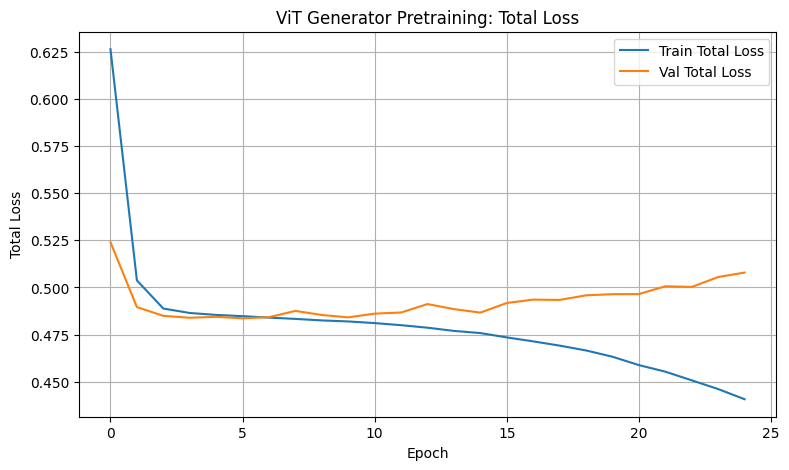

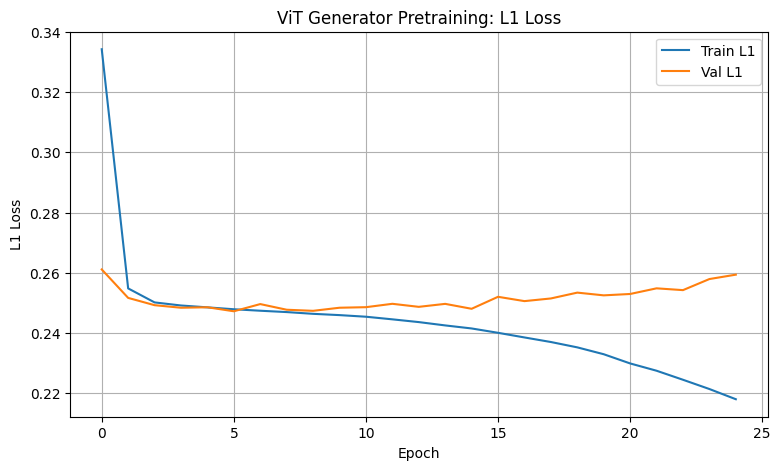

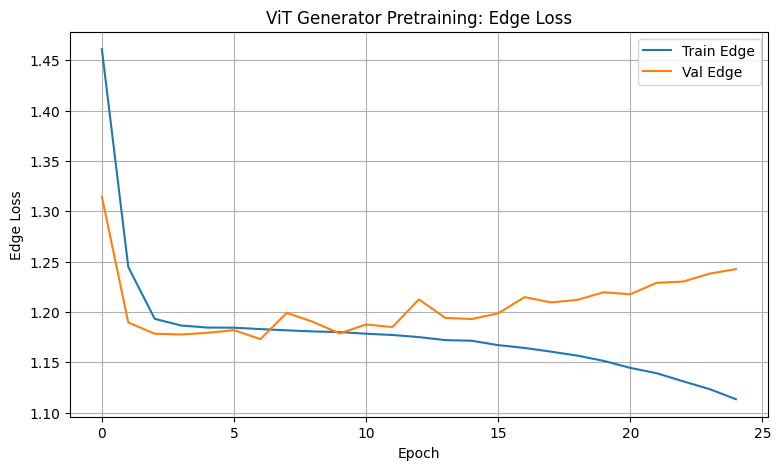

In [16]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import numpy as np

# ==============================
# CELL 16: Pretrain ViT Generator
# Loss = L1 + Edge Loss
# ==============================

PRETRAIN_CKPT_DIR = "/kaggle/working/mindbig_pretrain_checkpoints"
os.makedirs(PRETRAIN_CKPT_DIR, exist_ok=True)

PRETRAIN_BEST_PATH = os.path.join(PRETRAIN_CKPT_DIR, "best_pretrained_vit_generator.pth")
PRETRAIN_LAST_PATH = os.path.join(PRETRAIN_CKPT_DIR, "last_pretrained_vit_generator.pth")

NUM_EPOCHS = 25
LEARNING_RATE = 1e-4

LAMBDA_L1 = 1.0
LAMBDA_EDGE = 0.2

# ------------------------------
# Edge Loss using Sobel filters
# ------------------------------
class EdgeLoss(nn.Module):
    def __init__(self):
        super().__init__()

        sobel_x = torch.tensor(
            [[-1, 0, 1],
             [-2, 0, 2],
             [-1, 0, 1]],
            dtype=torch.float32
        ).view(1, 1, 3, 3)

        sobel_y = torch.tensor(
            [[-1, -2, -1],
             [ 0,  0,  0],
             [ 1,  2,  1]],
            dtype=torch.float32
        ).view(1, 1, 3, 3)

        self.register_buffer("sobel_x", sobel_x)
        self.register_buffer("sobel_y", sobel_y)

    def get_edges(self, img):
        # img shape: (B, 1, 28, 28)
        edge_x = F.conv2d(img, self.sobel_x, padding=1)
        edge_y = F.conv2d(img, self.sobel_y, padding=1)
        edge = torch.sqrt(edge_x ** 2 + edge_y ** 2 + 1e-6)
        return edge

    def forward(self, pred, target):
        pred_edge = self.get_edges(pred)
        target_edge = self.get_edges(target)
        return F.l1_loss(pred_edge, target_edge)


criterion_l1 = nn.L1Loss()
criterion_edge = EdgeLoss().to(device)

pretrain_optimizer = optim.Adam(
    pretrain_generator.parameters(),
    lr=LEARNING_RATE,
    betas=(0.9, 0.999),
    weight_decay=1e-5
)

best_val_loss = float("inf")

pretrain_history = {
    "train_total_loss": [],
    "train_l1_loss": [],
    "train_edge_loss": [],
    "val_total_loss": [],
    "val_l1_loss": [],
    "val_edge_loss": []
}

print("========== GENERATOR PRETRAINING STARTED ==========")
print("Model       : Fresh ViTEEGGenerator")
print("Epochs      :", NUM_EPOCHS)
print("LR          :", LEARNING_RATE)
print("Loss        : L1 + Edge Loss")
print("LAMBDA_L1   :", LAMBDA_L1)
print("LAMBDA_EDGE :", LAMBDA_EDGE)
print("Checkpoint  :", PRETRAIN_CKPT_DIR)


for epoch in range(1, NUM_EPOCHS + 1):

    # ==============================
    # Train phase
    # ==============================
    pretrain_generator.train()

    train_total = 0.0
    train_l1_total = 0.0
    train_edge_total = 0.0

    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS} [Pretrain]")

    for batch in train_pbar:
        eeg = batch["eeg"].to(device)
        target_img = batch["image"].to(device)

        pretrain_optimizer.zero_grad()

        pred_img = pretrain_generator(eeg)

        loss_l1 = criterion_l1(pred_img, target_img)
        loss_edge = criterion_edge(pred_img, target_img)

        loss_total = (LAMBDA_L1 * loss_l1) + (LAMBDA_EDGE * loss_edge)

        loss_total.backward()
        torch.nn.utils.clip_grad_norm_(pretrain_generator.parameters(), max_norm=1.0)
        pretrain_optimizer.step()

        batch_size = eeg.size(0)

        train_total += loss_total.item() * batch_size
        train_l1_total += loss_l1.item() * batch_size
        train_edge_total += loss_edge.item() * batch_size

        train_pbar.set_postfix({
            "Total": f"{loss_total.item():.4f}",
            "L1": f"{loss_l1.item():.4f}",
            "Edge": f"{loss_edge.item():.4f}"
        })

    epoch_train_total = train_total / len(train_dataset)
    epoch_train_l1 = train_l1_total / len(train_dataset)
    epoch_train_edge = train_edge_total / len(train_dataset)

    # ==============================
    # Validation phase
    # ==============================
    pretrain_generator.eval()

    val_total = 0.0
    val_l1_total = 0.0
    val_edge_total = 0.0

    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS} [Val]"):
            eeg = batch["eeg"].to(device)
            target_img = batch["image"].to(device)

            pred_img = pretrain_generator(eeg)

            loss_l1 = criterion_l1(pred_img, target_img)
            loss_edge = criterion_edge(pred_img, target_img)

            loss_total = (LAMBDA_L1 * loss_l1) + (LAMBDA_EDGE * loss_edge)

            batch_size = eeg.size(0)

            val_total += loss_total.item() * batch_size
            val_l1_total += loss_l1.item() * batch_size
            val_edge_total += loss_edge.item() * batch_size

    epoch_val_total = val_total / len(val_dataset)
    epoch_val_l1 = val_l1_total / len(val_dataset)
    epoch_val_edge = val_edge_total / len(val_dataset)

    pretrain_history["train_total_loss"].append(epoch_train_total)
    pretrain_history["train_l1_loss"].append(epoch_train_l1)
    pretrain_history["train_edge_loss"].append(epoch_train_edge)

    pretrain_history["val_total_loss"].append(epoch_val_total)
    pretrain_history["val_l1_loss"].append(epoch_val_l1)
    pretrain_history["val_edge_loss"].append(epoch_val_edge)

    print(
        f"Epoch [{epoch:02d}/{NUM_EPOCHS}] "
        f"Train Total: {epoch_train_total:.5f} | "
        f"Train L1: {epoch_train_l1:.5f} | "
        f"Train Edge: {epoch_train_edge:.5f} || "
        f"Val Total: {epoch_val_total:.5f} | "
        f"Val L1: {epoch_val_l1:.5f} | "
        f"Val Edge: {epoch_val_edge:.5f}"
    )

    # ==============================
    # Save best checkpoint
    # ==============================
    if epoch_val_total < best_val_loss:
        best_val_loss = epoch_val_total

        torch.save({
            "epoch": epoch,
            "model_state_dict": pretrain_generator.state_dict(),
            "optimizer_state_dict": pretrain_optimizer.state_dict(),
            "best_val_loss": best_val_loss,
            "history": pretrain_history,
            "lambda_l1": LAMBDA_L1,
            "lambda_edge": LAMBDA_EDGE
        }, PRETRAIN_BEST_PATH)

        print(f"Best pretrained generator saved at epoch {epoch} | Best Val Total: {best_val_loss:.5f}")

    # Save last checkpoint
    torch.save({
        "epoch": epoch,
        "model_state_dict": pretrain_generator.state_dict(),
        "optimizer_state_dict": pretrain_optimizer.state_dict(),
        "best_val_loss": best_val_loss,
        "history": pretrain_history,
        "lambda_l1": LAMBDA_L1,
        "lambda_edge": LAMBDA_EDGE
    }, PRETRAIN_LAST_PATH)


print("\n========== PRETRAINING FINISHED ==========")
print("Best Val Total Loss:", best_val_loss)
print("Best checkpoint:", PRETRAIN_BEST_PATH)
print("Last checkpoint:", PRETRAIN_LAST_PATH)


# ==============================
# Plot curves
# ==============================

plt.figure(figsize=(9, 5))
plt.plot(pretrain_history["train_total_loss"], label="Train Total Loss")
plt.plot(pretrain_history["val_total_loss"], label="Val Total Loss")
plt.xlabel("Epoch")
plt.ylabel("Total Loss")
plt.title("ViT Generator Pretraining: Total Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(pretrain_history["train_l1_loss"], label="Train L1")
plt.plot(pretrain_history["val_l1_loss"], label="Val L1")
plt.xlabel("Epoch")
plt.ylabel("L1 Loss")
plt.title("ViT Generator Pretraining: L1 Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(pretrain_history["train_edge_loss"], label="Train Edge")
plt.plot(pretrain_history["val_edge_loss"], label="Val Edge")
plt.xlabel("Epoch")
plt.ylabel("Edge Loss")
plt.title("ViT Generator Pretraining: Edge Loss")
plt.legend()
plt.grid(True)
plt.show()

Loading best pretrained generator from:
/kaggle/working/mindbig_pretrain_checkpoints/best_pretrained_vit_generator.pth

========== BEST PRETRAIN CHECKPOINT INFO ==========
Best epoch      : 6
Best val loss   : 0.48359447615487233
Lambda L1       : 1.0
Lambda Edge     : 0.2

========== ONE VAL BATCH CHECK ==========
EEG shape        : torch.Size([32, 1, 64, 200])
Target shape     : torch.Size([32, 1, 28, 28])
Generated shape  : torch.Size([32, 1, 28, 28])
Batch L1 loss    : 0.26954883337020874

========== VALUE RANGE CHECK ==========
Target min/max   : -1.0 1.0
Generated min/max: -1.0 0.6166104078292847

========== IMAGE STATISTICS ==========
Target mean/std   : 0.13601267337799072 0.30776846408843994
Generated mean/std: 0.054224252700805664 0.150260329246521


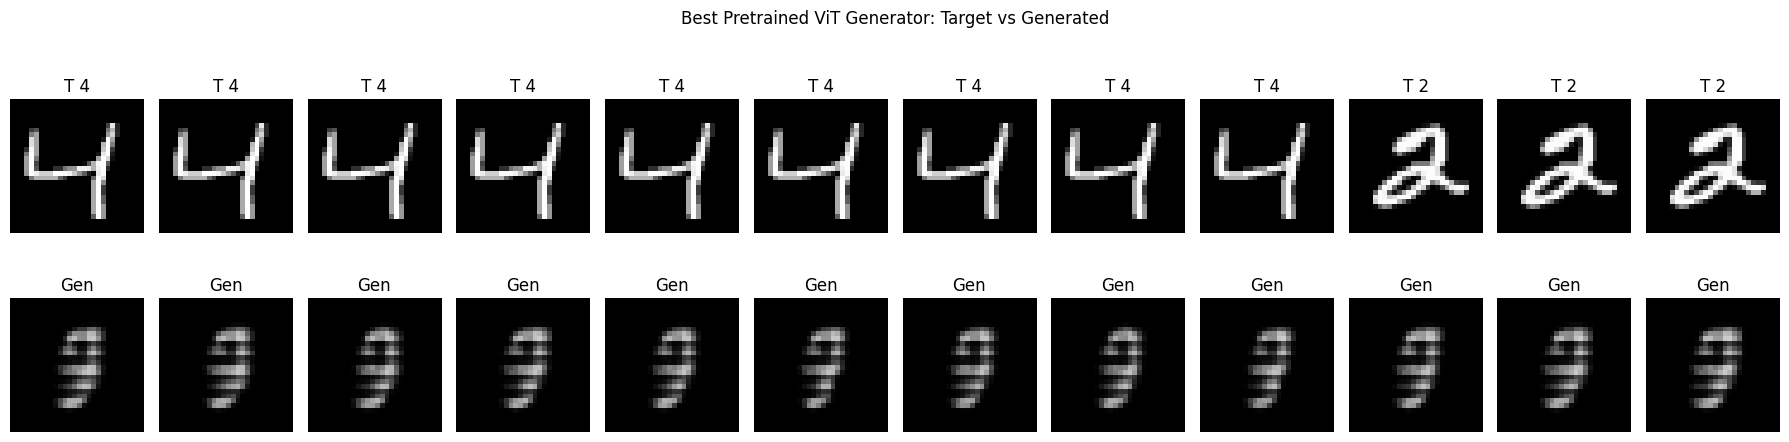


========== COLLAPSE CHECK ==========
Mean pixel-wise std across generated batch: 0.00677146390080452


In [17]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import os
import numpy as np

# ==============================
# CELL 17: Visualize best pretrained generator
# ==============================

PRETRAIN_BEST_PATH = "/kaggle/working/mindbig_pretrain_checkpoints/best_pretrained_vit_generator.pth"

print("Loading best pretrained generator from:")
print(PRETRAIN_BEST_PATH)

if not os.path.exists(PRETRAIN_BEST_PATH):
    raise FileNotFoundError(f"Checkpoint not found: {PRETRAIN_BEST_PATH}")

checkpoint = torch.load(PRETRAIN_BEST_PATH, map_location=device)

# Load into pretrain_generator
pretrain_generator.load_state_dict(checkpoint["model_state_dict"])
pretrain_generator = pretrain_generator.to(device)
pretrain_generator.eval()

print("\n========== BEST PRETRAIN CHECKPOINT INFO ==========")
print("Best epoch      :", checkpoint["epoch"])
print("Best val loss   :", checkpoint["best_val_loss"])
print("Lambda L1       :", checkpoint["lambda_l1"])
print("Lambda Edge     :", checkpoint["lambda_edge"])

# Take validation batch
batch = next(iter(val_loader))

eeg = batch["eeg"].to(device)
target = batch["image"].to(device)
labels = batch["label"]

with torch.no_grad():
    generated = pretrain_generator(eeg)

l1_loss = nn.L1Loss()(generated, target).item()

print("\n========== ONE VAL BATCH CHECK ==========")
print("EEG shape        :", eeg.shape)
print("Target shape     :", target.shape)
print("Generated shape  :", generated.shape)
print("Batch L1 loss    :", l1_loss)

print("\n========== VALUE RANGE CHECK ==========")
print("Target min/max   :", target.min().item(), target.max().item())
print("Generated min/max:", generated.min().item(), generated.max().item())

# Convert [-1,1] -> [0,1]
target_01 = (target.detach().cpu() + 1.0) / 2.0
generated_01 = (generated.detach().cpu() + 1.0) / 2.0

print("\n========== IMAGE STATISTICS ==========")
print("Target mean/std   :", target_01.mean().item(), target_01.std().item())
print("Generated mean/std:", generated_01.mean().item(), generated_01.std().item())

# Visualize
num_show = 12

plt.figure(figsize=(18, 5))

for i in range(num_show):
    target_img = target_01[i].squeeze(0)
    gen_img = generated_01[i].squeeze(0)

    plt.subplot(2, num_show, i + 1)
    plt.imshow(target_img, cmap="gray", vmin=0, vmax=1)
    plt.title(f"T {labels[i].item()}")
    plt.axis("off")

    plt.subplot(2, num_show, num_show + i + 1)
    plt.imshow(gen_img, cmap="gray", vmin=0, vmax=1)
    plt.title("Gen")
    plt.axis("off")

plt.suptitle("Best Pretrained ViT Generator: Target vs Generated")
plt.tight_layout()
plt.show()


# Extra: check if generated outputs are all similar
generated_flat = generated_01.view(generated_01.size(0), -1)
pairwise_std = generated_flat.std(dim=0).mean().item()

print("\n========== COLLAPSE CHECK ==========")
print("Mean pixel-wise std across generated batch:", pairwise_std)

if pairwise_std < 0.03:
    print("Warning: Generated outputs are very similar. Possible collapse / average output.")
else:
    print("Generated outputs have some variation.")

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ==============================
# CELL 18: EEG ViT Classifier Definition + Forward Check
# ==============================

class EEGViTClassifier(nn.Module):
    def __init__(
        self,
        input_channels=1,
        eeg_height=64,
        eeg_width=200,
        patch_size=(8, 20),
        embed_dim=128,
        depth=4,
        num_heads=8,
        mlp_ratio=4.0,
        dropout=0.1,
        num_classes=10
    ):
        super().__init__()

        self.patch_h, self.patch_w = patch_size
        assert eeg_height % self.patch_h == 0, "EEG height must be divisible by patch_h"
        assert eeg_width % self.patch_w == 0, "EEG width must be divisible by patch_w"

        self.grid_h = eeg_height // self.patch_h
        self.grid_w = eeg_width // self.patch_w
        self.num_patches = self.grid_h * self.grid_w

        # Patch embedding
        self.patch_embed = nn.Conv2d(
            input_channels,
            embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )  # (B, embed_dim, 8, 10)

        # CLS token
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))

        # Positional embedding
        self.pos_embed = nn.Parameter(torch.randn(1, 1 + self.num_patches, embed_dim) * 0.02)
        self.dropout = nn.Dropout(dropout)

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=int(embed_dim * mlp_ratio),
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)

        # Final classification head
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Sequential(
            nn.Linear(embed_dim, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # x: (B, 1, 64, 200)

        x = self.patch_embed(x)  # (B, embed_dim, 8, 10)
        B, C, H, W = x.shape

        x = x.flatten(2).transpose(1, 2)  # (B, num_patches, embed_dim)

        cls_tokens = self.cls_token.expand(B, -1, -1)  # (B,1,embed_dim)
        x = torch.cat([cls_tokens, x], dim=1)          # (B, 1+num_patches, embed_dim)

        x = x + self.pos_embed
        x = self.dropout(x)

        x = self.transformer(x)                        # (B, 1+num_patches, embed_dim)

        cls_out = x[:, 0]                              # CLS token output
        cls_out = self.norm(cls_out)

        logits = self.head(cls_out)                    # (B, 10)
        return logits


# ------------------------------
# Instantiate classifier
# ------------------------------
eeg_classifier = EEGViTClassifier(
    patch_size=(8, 20),
    embed_dim=128,
    depth=4,
    num_heads=8,
    mlp_ratio=4.0,
    dropout=0.1,
    num_classes=10
).to(device)

# Parameter count
total_params = sum(p.numel() for p in eeg_classifier.parameters())
trainable_params = sum(p.numel() for p in eeg_classifier.parameters() if p.requires_grad)

print("========== EEG CLASSIFIER INFO ==========")
print("Model              : EEGViTClassifier")
print("Total params       :", total_params)
print("Trainable params   :", trainable_params)

# ------------------------------
# Forward check
# ------------------------------
batch = next(iter(train_loader))

eeg = batch["eeg"].to(device)
labels = batch["label"].to(device)

eeg_classifier.eval()
with torch.no_grad():
    logits = eeg_classifier(eeg)
    probs = torch.softmax(logits, dim=1)
    preds = torch.argmax(probs, dim=1)

print("\n========== FORWARD CHECK ==========")
print("EEG input shape    :", eeg.shape)
print("Label shape        :", labels.shape)
print("Logits shape       :", logits.shape)
print("Probs shape        :", probs.shape)
print("Predictions shape  :", preds.shape)

print("\nSample true labels :", labels[:10].tolist())
print("Sample pred labels :", preds[:10].tolist())

print("\nLogits min/max     :", logits.min().item(), logits.max().item())
print("Prob min/max       :", probs.min().item(), probs.max().item())

========== EEG CLASSIFIER INFO ==========
Model              : EEGViTClassifier
Total params       : 842250
Trainable params   : 842250

========== FORWARD CHECK ==========
EEG input shape    : torch.Size([32, 1, 64, 200])
Label shape        : torch.Size([32])
Logits shape       : torch.Size([32, 10])
Probs shape        : torch.Size([32, 10])
Predictions shape  : torch.Size([32])

Sample true labels : [1, 8, 7, 1, 1, 4, 4, 1, 9, 5]
Sample pred labels : [7, 6, 7, 7, 7, 6, 7, 6, 7, 7]

Logits min/max     : -0.5461997985839844 0.38312897086143494
Prob min/max       : 0.05945928394794464 0.14587709307670593


/tmp/ipykernel_23/3577759563.py:58: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)


Train label counts: {np.int64(0): 720, np.int64(1): 873, np.int64(2): 720, np.int64(3): 702, np.int64(4): 765, np.int64(5): 657, np.int64(6): 675, np.int64(7): 873, np.int64(8): 639, np.int64(9): 720}
Class weights: [1.02      0.8412371 1.02      1.0461539 0.96      1.1178082 1.088
 0.8412371 1.1492958 1.02     ]

========== EEG CLASSIFIER TRAINING STARTED ==========
Model       : EEGViTClassifier
Epochs      : 20
LR          : 0.0001
Weight decay: 0.0001
Loss        : Weighted CrossEntropyLoss
Checkpoint  : /kaggle/working/mindbig_classifier_checkpoints


Epoch 1/20 [Classifier Train]:   0%|          | 0/230 [00:00<?, ?it/s]

Epoch 1/20 [Classifier Val]:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch [01/20] Train Loss: 2.31330 | Train Acc: 9.65% || Val Loss: 2.30677 | Val Acc: 8.63% | LR: 0.000100
Best classifier saved at epoch 1 | Best Val Acc: 8.63%


Epoch 2/20 [Classifier Train]:   0%|          | 0/230 [00:00<?, ?it/s]

...

Epoch 12/20 [Classifier Val]:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch [12/20] Train Loss: 2.08872 | Train Acc: 24.55% || Val Loss: 2.48551 | Val Acc: 9.21% | LR: 0.000050


Epoch 13/20 [Classifier Train]:   0%|          | 0/230 [00:00<?, ?it/s]

Epoch 13/20 [Classifier Val]:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch [13/20] Train Loss: 2.06812 | Train Acc: 25.97% || Val Loss: 2.51078 | Val Acc: 9.02% | LR: 0.000025

Early stopping triggered at epoch 13.

========== CLASSIFIER TRAINING FINISHED ==========
Best Val Acc : 11.3015873015873
Best Val Loss: 2.3409805322071864
Best checkpoint: /kaggle/working/mindbig_classifier_checkpoints/best_eeg_vit_classifier.pth
Last checkpoint: /kaggle/working/mindbig_classifier_checkpoints/last_eeg_vit_classifier.pth


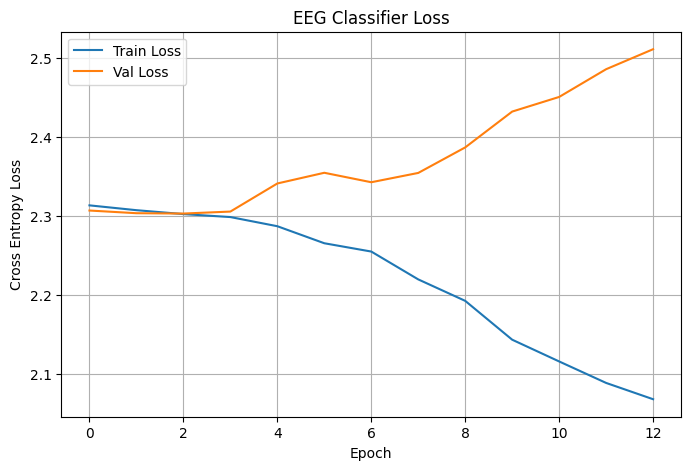

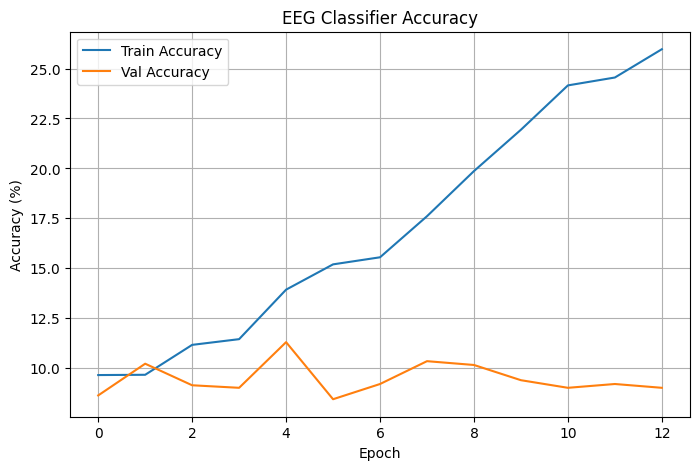

In [19]:
import os
import h5py
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# ==============================
# CELL 19: Train EEG ViT Classifier
# ==============================

CLASSIFIER_CKPT_DIR = "/kaggle/working/mindbig_classifier_checkpoints"
os.makedirs(CLASSIFIER_CKPT_DIR, exist_ok=True)

BEST_CLASSIFIER_PATH = os.path.join(CLASSIFIER_CKPT_DIR, "best_eeg_vit_classifier.pth")
LAST_CLASSIFIER_PATH = os.path.join(CLASSIFIER_CKPT_DIR, "last_eeg_vit_classifier.pth")

NUM_EPOCHS = 20
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
PATIENCE = 8

# ------------------------------
# Class weights from train labels
# ------------------------------
with h5py.File(H5_SAVE_PATH, "r") as h5:
    train_labels_np = h5["train"]["label"][:]

label_counts = Counter(train_labels_np)
print("Train label counts:", dict(sorted(label_counts.items())))

num_classes = 10
total_train = len(train_labels_np)

class_weights = []
for c in range(num_classes):
    count_c = label_counts[c]
    weight_c = total_train / (num_classes * count_c)
    class_weights.append(weight_c)

class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("Class weights:", class_weights.detach().cpu().numpy())

# ------------------------------
# Loss, optimizer, scheduler
# ------------------------------
criterion_cls = nn.CrossEntropyLoss(weight=class_weights)

optimizer_cls = optim.AdamW(
    eeg_classifier.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_cls,
    mode="max",
    factor=0.5,
    patience=3
)

best_val_acc = 0.0
best_val_loss = float("inf")
epochs_without_improvement = 0

history_cls = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

print("\n========== EEG CLASSIFIER TRAINING STARTED ==========")
print("Model       : EEGViTClassifier")
print("Epochs      :", NUM_EPOCHS)
print("LR          :", LEARNING_RATE)
print("Weight decay:", WEIGHT_DECAY)
print("Loss        : Weighted CrossEntropyLoss")
print("Checkpoint  :", CLASSIFIER_CKPT_DIR)


def compute_accuracy(logits, labels):
    preds = torch.argmax(logits, dim=1)
    correct = (preds == labels).sum().item()
    total = labels.size(0)
    return correct, total


for epoch in range(1, NUM_EPOCHS + 1):

    # ==============================
    # Train phase
    # ==============================
    eeg_classifier.train()

    train_loss_total = 0.0
    train_correct = 0
    train_total = 0

    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS} [Classifier Train]")

    for batch in train_pbar:
        eeg = batch["eeg"].to(device)
        labels = batch["label"].to(device)

        optimizer_cls.zero_grad()

        logits = eeg_classifier(eeg)
        loss = criterion_cls(logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(eeg_classifier.parameters(), max_norm=1.0)
        optimizer_cls.step()

        batch_size = eeg.size(0)
        train_loss_total += loss.item() * batch_size

        correct, total = compute_accuracy(logits, labels)
        train_correct += correct
        train_total += total

        train_pbar.set_postfix({
            "Loss": f"{loss.item():.4f}",
            "Acc": f"{100 * train_correct / train_total:.2f}%"
        })

    epoch_train_loss = train_loss_total / train_total
    epoch_train_acc = train_correct / train_total

    # ==============================
    # Validation phase
    # ==============================
    eeg_classifier.eval()

    val_loss_total = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS} [Classifier Val]"):
            eeg = batch["eeg"].to(device)
            labels = batch["label"].to(device)

            logits = eeg_classifier(eeg)
            loss = criterion_cls(logits, labels)

            batch_size = eeg.size(0)
            val_loss_total += loss.item() * batch_size

            correct, total = compute_accuracy(logits, labels)
            val_correct += correct
            val_total += total

    epoch_val_loss = val_loss_total / val_total
    epoch_val_acc = val_correct / val_total

    scheduler.step(epoch_val_acc)

    history_cls["train_loss"].append(epoch_train_loss)
    history_cls["val_loss"].append(epoch_val_loss)
    history_cls["train_acc"].append(epoch_train_acc)
    history_cls["val_acc"].append(epoch_val_acc)

    current_lr = optimizer_cls.param_groups[0]["lr"]

    print(
        f"Epoch [{epoch:02d}/{NUM_EPOCHS}] "
        f"Train Loss: {epoch_train_loss:.5f} | "
        f"Train Acc: {epoch_train_acc*100:.2f}% || "
        f"Val Loss: {epoch_val_loss:.5f} | "
        f"Val Acc: {epoch_val_acc*100:.2f}% | "
        f"LR: {current_lr:.6f}"
    )

    # ==============================
    # Save best checkpoint by validation accuracy
    # ==============================
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        best_val_loss = epoch_val_loss
        epochs_without_improvement = 0

        torch.save({
            "epoch": epoch,
            "model_state_dict": eeg_classifier.state_dict(),
            "optimizer_state_dict": optimizer_cls.state_dict(),
            "best_val_acc": best_val_acc,
            "best_val_loss": best_val_loss,
            "history": history_cls
        }, BEST_CLASSIFIER_PATH)

        print(
            f"Best classifier saved at epoch {epoch} | "
            f"Best Val Acc: {best_val_acc*100:.2f}%"
        )

    else:
        epochs_without_improvement += 1

    # Save last checkpoint
    torch.save({
        "epoch": epoch,
        "model_state_dict": eeg_classifier.state_dict(),
        "optimizer_state_dict": optimizer_cls.state_dict(),
        "best_val_acc": best_val_acc,
        "best_val_loss": best_val_loss,
        "history": history_cls
    }, LAST_CLASSIFIER_PATH)

    # Early stopping
    if epochs_without_improvement >= PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch}.")
        break


print("\n========== CLASSIFIER TRAINING FINISHED ==========")
print("Best Val Acc :", best_val_acc * 100)
print("Best Val Loss:", best_val_loss)
print("Best checkpoint:", BEST_CLASSIFIER_PATH)
print("Last checkpoint:", LAST_CLASSIFIER_PATH)


# ==============================
# Plot curves
# ==============================
plt.figure(figsize=(8, 5))
plt.plot(history_cls["train_loss"], label="Train Loss")
plt.plot(history_cls["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.title("EEG Classifier Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(np.array(history_cls["train_acc"]) * 100, label="Train Accuracy")
plt.plot(np.array(history_cls["val_acc"]) * 100, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("EEG Classifier Accuracy")
plt.legend()
plt.grid(True)
plt.show()